# Assignment 1

# Task 1: Exploratory Data Analysis (EDA)


- Libraries Import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import KNNImputer
import math

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

from sklearn.preprocessing import MinMaxScaler

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


from sklearn.model_selection import GridSearchCV, KFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score



df = pd.read_csv("car_price.csv")

- Dimensions of the data & the first 15 rows.

In [2]:
print(f'rows and columns number: {df.shape}')
df.head(15)

rows and columns number: (72435, 10)


,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
0,A1,2017.0,12500.0,Manual,15735.0,Petrol,150.0,55.4,1.4,audi
1,A6,2016.0,16500.0,Automatic,36203.0,Diesel,20.0,64.2,2.0,audi
2,A1,2016.0,11000.0,Manual,29946.0,Petrol,30.0,55.4,1.4,audi
3,A4,2017.0,16800.0,Automatic,25952.0,Diesel,145.0,67.3,2.0,audi
4,A3,2019.0,17300.0,Manual,1998.0,Petrol,145.0,49.6,1.0,audi
5,A1,2016.0,13900.0,Automatic,32260.0,Petrol,30.0,58.9,1.4,audi
6,A6,2016.0,13250.0,Automatic,76788.0,Diesel,30.0,61.4,2.0,audi
7,A4,2016.0,11750.0,NaN,75185.0,Diesel,20.0,70.6,2.0,audi
8,A3,2015.0,10200.0,Manual,46112.0,Petrol,20.0,60.1,1.4,audi
9,A1,2016.0,12000.0,Manual,22451.0,NaN,30.0,55.4,1.4,audi


- knowing the categorical and numerical features.

In [3]:
df.info()
print("Numerical Features:")
print(df.select_dtypes(include=np.number).columns)
print("\nCategorical Features:")
print(df.select_dtypes(exclude=np.number).columns)

<class 'pandas.DataFrame'>
RangeIndex: 72435 entries, 0 to 72434
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         68814 non-null  str    
 1   year          68813 non-null  float64
 2   price         68814 non-null  float64
 3   transmission  68812 non-null  str    
 4   mileage       68813 non-null  float64
 5   fuelType      68813 non-null  str    
 6   tax           68814 non-null  float64
 7   mpg           68814 non-null  float64
 8   engineSize    68813 non-null  float64
 9   Make          68814 non-null  str    
dtypes: float64(6), str(4)
memory usage: 5.5 MB
Numerical Features:
Index(['year', 'price', 'mileage', 'tax', 'mpg', 'engineSize'], dtype='str')

Categorical Features:
Index(['model', 'transmission', 'fuelType', 'Make'], dtype='str')


- Description of data


In [4]:
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,68813.000000,68814.000000,68813.000000,68814.000000,68814.000000,68813.000000
mean,2017.077660,16583.919261,23179.439539,116.930421,55.836352,1.635373
std,2.099474,9304.412707,21347.569657,64.081931,17.043643,0.561734
min,1996.000000,495.000000,1.000000,0.000000,0.300000,0.000000
25%,2016.000000,10167.250000,7199.000000,30.000000,47.900000,1.200000
50%,2017.000000,14495.000000,17521.000000,145.000000,55.400000,1.600000
75%,2019.000000,20359.750000,32478.000000,145.000000,62.800000,2.000000
max,2020.000000,145000.000000,323000.000000,580.000000,470.800000,6.600000


- determining the number of missing values in each feature.

In [5]:
df.isnull().sum()

model           3621
year            3622
price           3621
transmission    3623
mileage         3622
fuelType        3622
tax             3621
mpg             3621
engineSize      3622
Make            3621
dtype: int64

- Lets plot the histogram of the price to show the distribution.
- Rice Rule: Bins = 2 * cubic root(n), this is generally better for larger datasets.

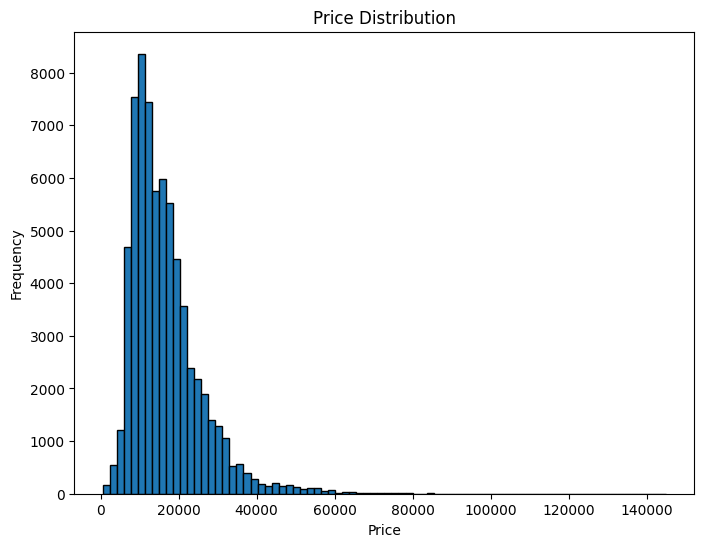

In [6]:
plt.figure(figsize=(8,6))
plt.hist(
    df['price'],
    bins=80,
    edgecolor='black'
)
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.title("Price Distribution")
plt.show()

- it shows that it is right skewed!

- Compute correlation matrix for numerical features only, creating a heatmap to visualize relationships between those numerical features.

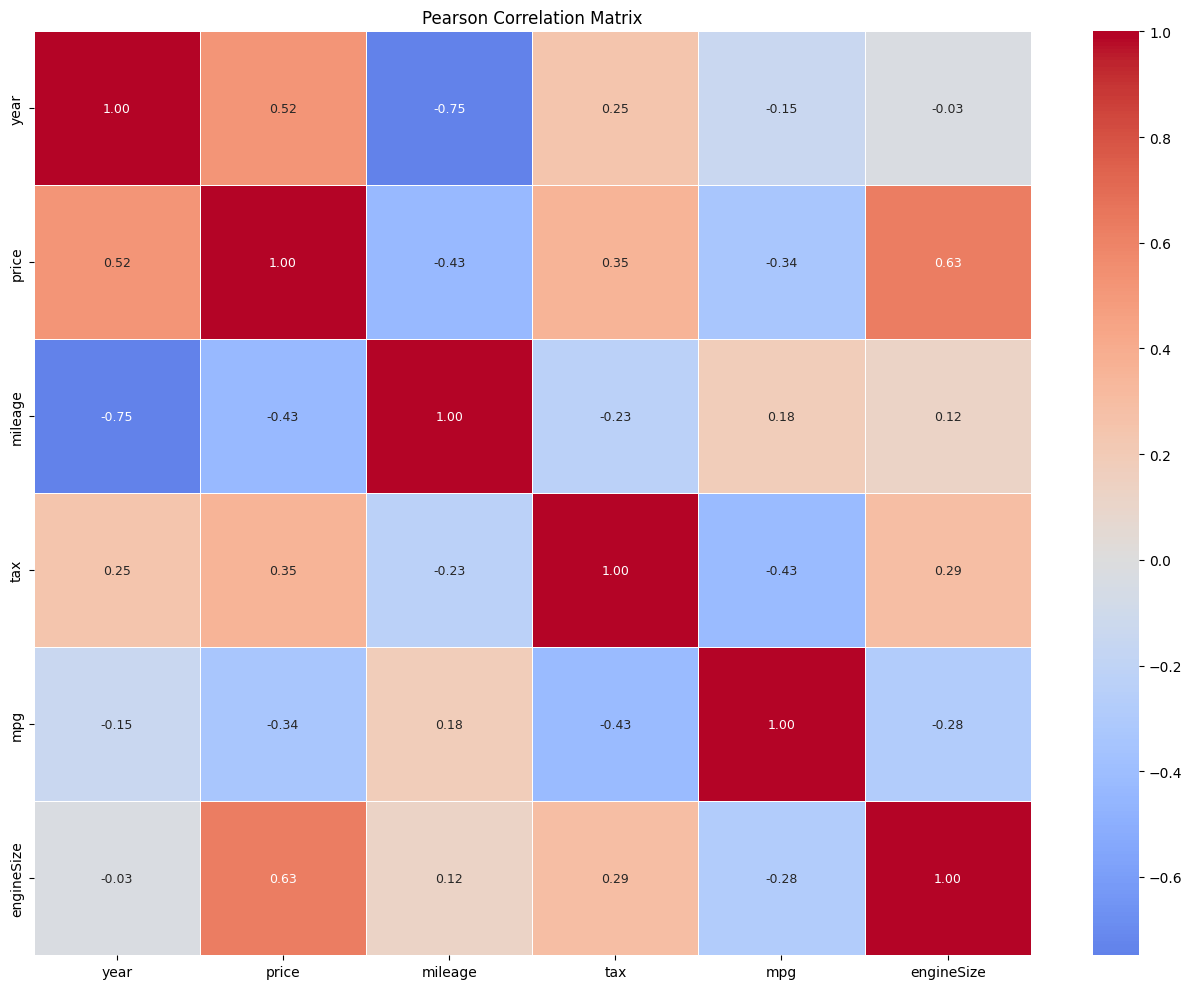

Top features related to Price:
price         1.000000
engineSize    0.629839
year          0.519383
tax           0.353204
mpg          -0.335615
mileage      -0.427524
Name: price, dtype: float64


In [7]:
corr = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(13, 10))
sns.heatmap(
    corr,
    annot=True,          # display correlation values
    fmt='.2f',           # show values with 2 decimal places
    cmap='coolwarm',     # color map for positive and negative correlation
    center=0,            # center colors around zero
    linewidths=0.4,
    annot_kws={'size': 9}
)

plt.title('Pearson Correlation Matrix')
plt.tight_layout()
plt.show()

# 1.00 (Dark Red): A perfect match. If one icreases, the other increase exactly the same way.
# -1.00 (Dark Blue): Perfect opposites. If one increases, the other decreases.
# 0.00 (White/Light): No connection at all. Changing one doesn't tell us anything about the other.

# the features that are mostly related to the price
print("Top features related to Price:")
print(corr['price'].sort_values(ascending=False))

# Task 2: Data Preprocessing

## 1) Train / test Split
- Also drop missing values from the price column to avoid errors, cause the price attribute is the targeted attribute to predict.

In [8]:
# Drop Na for price column
df = df.dropna(subset=['price'])

# Remove duplicates
df = df.drop_duplicates()

# Define features and target variable
X = df.drop(columns='price')
y = df['price']


x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1
)

print(f'Train: {x_train.shape}  |  Test: {x_test.shape}')

Train: (54769, 9)  |  Test: (13693, 9)


## 2) Handle missing values

- According to the number of missing values displayed in task1, to deal with the missing values we got, we can fill the missing values with means/medians in the float datatype columns, except the "year" column, which can be filled using KNN. Additionally, the problem of null values in string datatype columns can be solved using the mode function.

In [9]:
# Numerical Columns (Median)
num_cols = ['mileage', 'tax', "mpg", 'engineSize']

for col in num_cols:
    median_val = x_train[col].median()
    x_train[col] = x_train[col].fillna(median_val)
    x_test[col] = x_test[col].fillna(median_val)

# Categories Columns (Mod)
cat_cols = ['model', 'transmission', 'fuelType', 'Make']

for col in cat_cols:
    mode_val = x_train[col].mode()[0]
    x_train[col] = x_train[col].fillna(mode_val)
    x_test[col] = x_test[col].fillna(mode_val)

# Year Column (KNN)
year_cols = ['year']
k = max(1, int(math.sqrt(len(df))))

imputer = KNNImputer(n_neighbors=k)

x_train[year_cols] = imputer.fit_transform(x_train[year_cols])
x_test[year_cols] = imputer.transform(x_test[year_cols])

## 3) Encode categorical columns

- We use One-Hot Encoding, cause we have nominal data, not ordinal relationships on "model", "transmission", "fuelType", and "Make" Columns.

In [10]:
enc = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

train_enc = enc.fit_transform(x_train[cat_cols])
test_enc = enc.transform(x_test[cat_cols])

train_enc_df = pd.DataFrame(
    train_enc,
    columns=enc.get_feature_names_out(cat_cols),
    index=x_train.index
)

test_enc_df = pd.DataFrame(
    test_enc,
    columns=enc.get_feature_names_out(cat_cols),
    index=x_test.index
)

x_train = pd.concat([x_train.drop(columns=cat_cols), train_enc_df], axis=1)
x_test = pd.concat([x_test.drop(columns=cat_cols), test_enc_df], axis=1)


## 4) Detect and handle outliers
- to be able to use minmax scaling without errors or wrong values.

IQR outliers in price: 2114


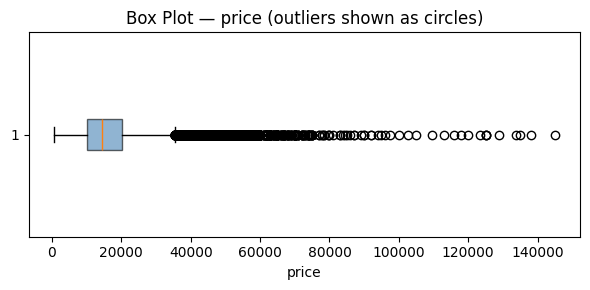

Training rows remaining after trimming: 52655


In [11]:
# --- IQR method on y_train ---
Q1 = y_train.quantile(0.25)
Q3 = y_train.quantile(0.75)
IQR = Q3 - Q1

lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

# Detect outliers
outliers_iqr = y_train[(y_train < lower) | (y_train > upper)]

print(f'IQR outliers in price: {len(outliers_iqr)}')


# Visualization
plt.figure(figsize=(6, 3))

plt.boxplot(
    y_train,
    vert=False,
    patch_artist=True,
    boxprops=dict(facecolor='steelblue', alpha=0.6)
)

plt.title('Box Plot — price (outliers shown as circles)')
plt.xlabel('price')
plt.tight_layout()
plt.show()

x_train = x_train.drop(index=outliers_iqr.index)
y_train = y_train.drop(index=outliers_iqr.index)
print(f"Training rows remaining after trimming: {len(y_train)}")

## 5) Scale numerical features
- Scaling the numerical data to avoid being biased by some features.
- We can use Standard Scaling and MinMax Scaling, especially after removing the outliers, which gives close results, but using MinMax Scaling is better, giving a range in [0,1], which improves KNN performance, because it is distance-based.

In [12]:
# Save copies before scaling
x_train_before_scaling = x_train.copy()
x_test_before_scaling = x_test.copy()

scaler = MinMaxScaler()

# Fit on train only
x_train[num_cols] = scaler.fit_transform(x_train[num_cols])

# Transform test
x_test[num_cols] = scaler.transform(x_test[num_cols])

# Task 3: Create Two Target Variables


## 1) The Regression Target Variable

In [13]:
y_reg = df['price']
print(y_reg.head())

0    12500.0
1    16500.0
2    11000.0
3    16800.0
4    17300.0
Name: price, dtype: float64


## 2) The Classification Target Variable

- Classification target using equal-frequency binning
- we will identify the thresholds based on the distribution (Histogram and the describe method)

In [14]:
print(df['price'].describe())

count     68462.000000
mean      16568.548275
std        9298.433764
min         495.000000
25%       10150.000000
50%       14495.000000
75%       20269.750000
max      145000.000000
Name: price, dtype: float64


- We used pd.qcut() to divide the continuous price feature into three equal-frequency categories.
- Since the price distribution is right-skewed
- qcut is more suitable than cut because it creates balanced classes, which improves KNN performance

In [15]:
# Create classification target using equal-frequency binning on training set only to avoid data leakage
y_train_cat, bin_edges = pd.qcut(
    y_train,
    q=3,
    labels=['Cheap', 'Moderate', 'Expensive'],
    retbins=True
)

# Apply the same boundaries to the test set
y_test_cat = pd.cut(
    y_test,
    bins=[-np.inf, *bin_edges[1:-1], np.inf],
    labels=['Cheap', 'Moderate', 'Expensive']
)

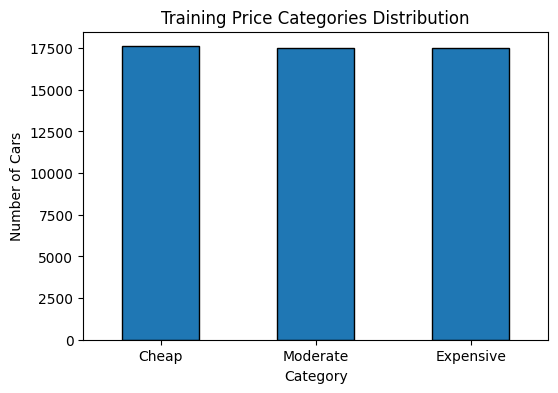

In [16]:
# Plotting the training price categories distribution
plt.figure(figsize=(6,4))
y_train_cat.value_counts().sort_index().plot(
    kind='bar',
    edgecolor='black'
)

plt.title("Training Price Categories Distribution")
plt.xlabel("Category")
plt.ylabel("Number of Cars")
plt.xticks(rotation=0)
plt.show()

In [17]:
# Display the number of cars in each category
print("\n=== Number of Cars in Each Category ===")
print("\nTraining Set (80%):")
print(y_train_cat.value_counts().sort_index())

print("\nTest Set (20%):")
print(y_test_cat.value_counts().sort_index())

# Display bin boundaries
print("\nPrice Boundaries:")
print(bin_edges)


=== Number of Cars in Each Category ===

Training Set (80%):
price
Cheap        17605
Moderate     17521
Expensive    17529
Name: count, dtype: int64

Test Set (20%):
price
Cheap        4458
Moderate     4368
Expensive    4867
Name: count, dtype: int64

Price Boundaries:
[  495. 11250. 17498. 35436.]


# Task 4: Model 1 - Linear Regression

- Using multivariable liner regression to predict the price for a given car according to its features.

R2 Score: 0.7765
Root Mean Squared Error: 4339.04


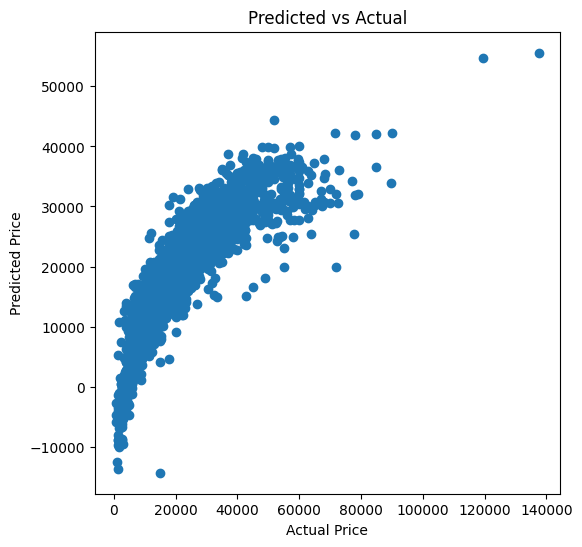

In [18]:
multi_model = LinearRegression()
multi_model.fit(x_train, y_train)

y_pred_multi = multi_model.predict(x_test)

# Evaluation
print(f"R2 Score: {r2_score(y_test, y_pred_multi):.4f}")
print(f"Root Mean Squared Error: {np.sqrt(mean_squared_error(y_test, y_pred_multi)):.2f}")

# Visualization: Predicted vs Actual
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_multi)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Predicted vs Actual")
plt.show()


# Task 5: Model 2: KNN Classification

Try different k values and distance metrics to find the best combination 

In [19]:
param_grid = {
    'n_neighbors': range(3, 31, 2),
    'metric': ['euclidean', 'manhattan']
}

# Initialize KNN model
knn = KNeighborsClassifier()

# Use 5-fold cross-validation for more reliable evaluation
kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Run Grid Search to test all parameter combinations and pick the best one
grid_search = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    cv=kfold,
    scoring='accuracy',
    n_jobs=-1
)

In [20]:
# Train the model on scaled training data (important for KNN)
grid_search.fit(x_train, y_train_cat)

# Show best parameters and corresponding accuracy
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV Accuracy: {grid_search.best_score_:.4f}")

Best Parameters: {'metric': 'manhattan', 'n_neighbors': 5}
Best CV Accuracy: 0.8650


In [21]:
# Use the best model to make predictions on test data
best_knn = grid_search.best_estimator_
y_pred = best_knn.predict(x_test)

# Evaluate model performance using accuracy and detailed metrics
print(f"Accuracy Score: {accuracy_score(y_test_cat, y_pred):.4f}")
print(classification_report(y_test_cat, y_pred))

Accuracy Score: 0.8742
              precision    recall  f1-score   support

       Cheap       0.91      0.90      0.90      4458
   Expensive       0.91      0.91      0.91      4867
    Moderate       0.80      0.81      0.81      4368

    accuracy                           0.87     13693
   macro avg       0.87      0.87      0.87     13693
weighted avg       0.87      0.87      0.87     13693



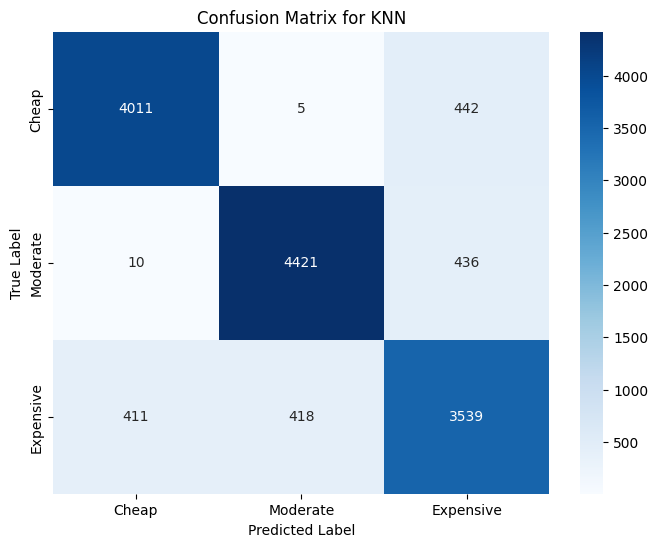

In [22]:
# Plot confusion matrix to see prediction errors between classes
plt.figure(figsize=(8, 6))

sns.heatmap(
    confusion_matrix(y_test_cat, y_pred),
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Cheap', 'Moderate', 'Expensive'],
    yticklabels=['Cheap', 'Moderate', 'Expensive']
)

plt.title('Confusion Matrix for KNN')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## the Confusion Matrix
- The confusion matrix shows how well the model sorts cars into three groups: Cheap, Moderate, and Expensive.

### Strong Accuracy at the Extremes (The Diagonal)
- The model is very good at identifying Cheap and Expensive cars. This is because these two groups have very clear differences. For example, expensive cars almost always have larger engines and lower mileage, while cheap cars show the opposite. The model recognizes these signatures easily.

### Overlap at the Borders (Boundary Errors)
- Most mistakes happen between categories that are next to each other (for example, calling a Moderate car Expensive). This happens because cars priced right at the cutoff line share almost identical features. It is mathematically difficult for the model to draw a perfect line when two cars are only a few dollars apart in price.

### Financial Impact (Buyer's Perspective)
- Errors in the model result in real-world risks or opportunities:
    False Positive (Overvaluation): The model labels a car as Expensive when it is actually Moderate. This is a Type I Error. For a buyer, this is a risk because they might end up overpaying for a mid-range car.
    False Negative (The Bargain): The model labels an Expensive car as Moderate. This is a Type II Error. For a buyer, this is a bargain, it identifies a high-value car that is priced lower than it should be.

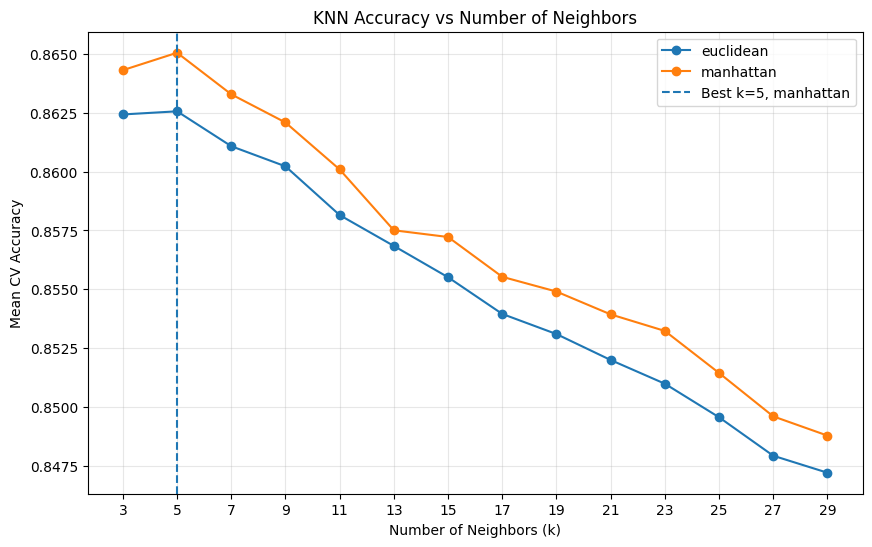

In [23]:
# Analyze how k and distance metric affect accuracy
results = pd.DataFrame(grid_search.cv_results_)
plt.figure(figsize=(10, 6))

for metric in ['euclidean', 'manhattan']:
    subset = results[results['param_metric'] == metric]

    plt.plot(
        subset['param_n_neighbors'],
        subset['mean_test_score'],
        marker='o',
        label=metric
    )

# Highlight the best k value
best_k = grid_search.best_params_['n_neighbors']
best_metric = grid_search.best_params_['metric']

plt.axvline(
    best_k,
    linestyle='--',
    label=f'Best k={best_k}, {best_metric}'
)

plt.title('KNN Accuracy vs Number of Neighbors')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Mean CV Accuracy')
plt.xticks(np.arange(3, 31, 2))
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Task 6: Analysis and Discussion

### Model Comparison

1) Which model performed better ?
- In the Regression context (Linear Regression): "Better" means accurately predicting the exact, continuous price of the vehicle. It is evaluated here using the R2 score (77.65%), which means the model successfully captures and explains roughly 78% of the variance in the actual car prices based on the input features.

- In the Classification context (KNN): "Better" means successfully sorting a car into the correct broad price category (cheap, moderate, expensive). It is evaluated here using Accuracy (87.42%), meaning the model placed the car into the correct category 87% of the time.

- While the KNN's 87.42% Accuracy appears numerically higher than the Linear Regression's 77.65% R2 score, a direct comparison is misleading because they are taking tests of different difficulties. The Linear Regression model is the better, more useful model. The KNN classifier achieves a higher score by grouping continuous prices into wide categories, giving it a massive, forgiving margin of error. It achieves this high accuracy precisely by sacrificing granular detail. The Linear Regression model takes on the much harder task of predicting exact prices and still performs strongly, preserving valuable and precise information about the vehicle's true market value.

2) Is classification easier than regression on this dataset ?
- Basically, classification is easier for the model because it doesn't have to guess the exact number; it just has to land in the right category. This gives it a huge margin for error. But getting a high accuracy score this way is kind of an illusion. By putting different prices together into one group, you lose a lot of detail. The model ends up treating a car at the very bottom of a category exactly the same as one at the top, making the final answer much less precise than regression.

3) Does converting price into categories lose important information?
- Yes, converting the exact car price into categories leads to a loss of important information.

- By grouping prices, the model becomes blind to differences within the same category. It ends up treating a $10k car and a $19k car as the exact same thing.

- Categorization forces rigid, "crisp" cutoffs. Two cars priced at $9,995 and $10,005 are virtually identical in reality, but a crisp $10k boundary forces the model to treat them as completely different classes. It assumes a sudden jump in meaning, rather than a gradual (or "fuzzy") real-world transition.

- The model forgets "how far off" it is. Guessing a car is "Cheap" when it is actually "Moderate" is penalized the exact same way as guessing "Cheap" when it is actually "Expensive."

### Sensitivity Analysis

*1) What happens if you remove the most correlated feature ?*

In [24]:
# Remove the most correlated feature
x_train_no_engine = x_train.drop(columns=['engineSize'])
x_test_no_engine = x_test.drop(columns=['engineSize'])

# Train regression model without Engine
model_no_engine = LinearRegression()
model_no_engine.fit(x_train_no_engine, y_train)

# Predict
y_pred_no_engine = model_no_engine.predict(x_test_no_engine)

# Evaluation
print("Original R Squared:",
      r2_score(y_test, y_pred_multi))

print("R Squared without Engine Size feature:",
      r2_score(y_test, y_pred_no_engine))

print("Original Root Mean Squared Error:",
      np.sqrt(mean_squared_error(y_test, y_pred_multi)))

print("Root Mean Squared Error without Engine Size feature:",
      np.sqrt(mean_squared_error(y_test, y_pred_no_engine)))

Original R Squared: 0.7765396362701164
R Squared without Engine Size feature: 0.7459945854446957
Original Root Mean Squared Error: 4339.043531107562
Root Mean Squared Error without Engine Size feature: 4626.102420905724


- Removing the most correlated feature (the Engine Size feature) caused a minor drop in performance. The R2 score decreased by only ~3% (77.65% to 74.60%), and the Root Mean Squared Error increased by just ~287. While 'Engine' was the strongest individual predictor, the remaining features contained enough overlapping information to successfully compensate for its absence, preventing major error in the model's predictive power.

In [25]:
# Remove the most correlated feature
x_train_knn = x_train.drop(columns=['engineSize'])
x_test_knn = x_test.drop(columns=['engineSize'])

knn = KNeighborsClassifier(n_neighbors=5, metric='manhattan')

knn.fit(x_train_knn, y_train_cat)

y_pred_knn = knn.predict(x_test_knn)


print("Accuracy with most correlated feature:",
      accuracy_score(y_test_cat, y_pred))

print("Accuracy without most correlated feature",
      accuracy_score(y_test_cat, y_pred_knn))

print("Performance drop:",
      accuracy_score(y_test_cat, y_pred) -accuracy_score(y_test_cat, y_pred_knn))

Accuracy with most correlated feature: 0.8742423135908859
Accuracy without most correlated feature 0.868253852333309
Performance drop: 0.005988461257576905


Removing the most correlated feature affects Linear Regression directly due to its linear dependency assumption, while in KNN it indirectly affects performance by changing the distance structure between data points in the feature space.The model’s accuracy decreased by a negligible 0.59% (from 87.42% to 86.83%), confirming that the performance remained stable. This minimal drop is due to feature redundancy: although engineSize is strongly related to price, other strong features like mileage and year carry similar information.This proves the KNN model is robust and does not rely on a single variable to maintain accurate price classification.

*2) Try running KNN without scaling*

In [26]:
# KNN without scaling
grid_search_no_scale = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid,
    cv=kfold,
    scoring='accuracy',
    n_jobs=-1
)

grid_search_no_scale.fit(
    x_train_before_scaling,
    y_train_cat
)

y_pred_no_scale = grid_search_no_scale.best_estimator_.predict(
    x_test_before_scaling
)

acc_no_scale = accuracy_score(y_test_cat, y_pred_no_scale)

print("Accuracy with scaling:",
      accuracy_score(y_test_cat, y_pred))

print("Accuracy without scaling:",
      acc_no_scale)

print("Performance drop:",
      accuracy_score(y_test_cat, y_pred) - acc_no_scale)

Accuracy with scaling: 0.8742423135908859
Accuracy without scaling: 0.6035930767545461
Performance drop: 0.2706492368363398


- Removing feature scaling resulted in a massive 27.1% drop in accuracy. This happens because KNN is a distance-based algorithm. In unscaled data, features with naturally large numbers (like mileage) completely overpower features with smaller numbers (like engine size) during the distance calculation. The 60.4% accuracy shows that without scaling, the model becomes blind to the smaller-scale features, leading to highly inaccurate predictions.

*3) Try a different threshold for your price categories*

In [27]:
y_train_alt, alt_bins = pd.qcut(
    y_train,
    q=[0, 0.4, 0.7, 1],
    labels=['Cheap', 'Moderate', 'Expensive'],
    retbins=True
)

y_test_alt = pd.cut(
    y_test,
    bins=[-np.inf, *alt_bins[1:-1], np.inf],
    labels=['Cheap', 'Moderate', 'Expensive']
)

knn_alt = KNeighborsClassifier(
    n_neighbors=best_k,
    metric=best_metric
)

knn_alt.fit(x_train, y_train_alt)

y_pred_alt = knn_alt.predict(x_test)

alt_accuracy = accuracy_score(y_test_alt, y_pred_alt)

print("Original Accuracy:",
      accuracy_score(y_test_cat, y_pred))

print("New Threshold Accuracy:",
      alt_accuracy)

print("Difference:",
      alt_accuracy - accuracy_score(y_test_cat, y_pred))

Original Accuracy: 0.8742423135908859
New Threshold Accuracy: 0.8708099028700796
Difference: -0.003432410720806245


- Modifying the price category thresholds led to a insignificant performance drop of just 0.34%. This proves that our original high accuracy wasn't just a fluke based on lucky boundary placement; the model is stable, robust, and consistently recognizes the core patterns in the data regardless of minor changes to the category definitions.

# Task 7: Required Visualizations

1) The Histogram ( In Task 1 EDA)
it helped us understand the distribution of car prices in the dataset.

​The distribution is clearly right-skewed, showing that most cars are concentrated in the lower to moderate price range, while only a few cars have very high prices.

​This observation was useful in Task 2, as it highlighted the presence of high-price outliers, which were later handled using the IQR method.

​It also supported our decision in Task 3 to divide prices into Cheap, Moderate, and Expensive categories using quantile-based splitting, since the data is not normally distributed.


2) correlation heatmap the (In Task 1 EDA)
The Heatmap served as a strategic roadmap for our feature selection, revealing how numerical variables interact with the car's price.

​The most significant finding was the strong positive correlation (0.63) between engine size and price, identifying it as the primary driver for our models. This was later validated in Task 6.2 (Sensitivity Analysis), where removing this feature caused a performance drop, confirming its predictive power while proving that the model still relies on a combination of other features.

​On the other hand, mileage showed a notable negative correlation (-0.43), aligning with the logical expectation that higher usage reduces a car's market value.

​Ultimately, this analysis provided the necessary 'feature intelligence' to refine both our Linear Regression (Task 4) and KNN Classification(Task 5), ensuring that our models are built on the most impactful data points.

3) Predicted vs. Actual scatter plot( in Task 4 ( Model 1: Linear Regression) )
This evaluates the performance of the Linear Regression model.

​The x-axis represents the actual car prices, while the y-axis represents the predicted prices generated by the model.

​From the plot, most points follow a clear increasing trend, which indicates that the model is able to capture the general relationship between the features and car price.

​However, the spread of points around the trend shows the presence of prediction errors, especially for higher price values. This is consistent with the obtained R Squared score of 0.7765, which means that the model explains approximately 77.65% of the variance in car prices.

​In addition, the RMSE value of 4339.04 indicates that the model’s predictions differ from the actual prices by an average of about 4339 units.

4) confusion matrix ( in Task 5 ( Model 2: KNN Classification ) )

​It evaluates the performance of the KNN classification model across the three price categories defined in Task 3.The rows represent the actual categories, while the columns represent the predicted categories.

​The high diagonal values indicate strong predictive performance, with the model correctly classifying
4011 Cheap cars,
4421 Moderate cars,
and 3539 Expensive cars.

​The off-diagonal values represent misclassifications, which mostly occur between neighboring categories.This is expected because cars near the category thresholds may share similar features.

​Overall, this visualization confirms the effectiveness and stability of the KNN model in predicting price categories .

Additional plots :

1) Box Plot (Task 2: Preprocessing )

to identify outliers in the target variable (price).

​The box represents the interquartile range, while the line inside the box shows the median price.
​The circles outside the whiskers represent outliers, which are cars with unusually high prices.
​This visualization was important for applying the IQR method to detect extreme values before training the models. Handling these outliers helped reduce their impact on the Linear Regression model and improved the overall data quality.


2) bar chart ( distribution of the training data )
three defined price categories: Cheap, Moderate, and Expensive.

​Class Balance: The dataset exhibits a uniform distribution, with each category comprising approximately 17,500 instances. This confirms that the classes are perfectly balanced.

​Methodology: This equilibrium was achieved through quantile-based splitting (qcut), which partitioned the target variable into three equal-frequency groups based on the price values.

​Impact on Modeling: Maintaining balanced classes is a critical step for Task 5 (KNN Classification). It ensures that the model does not develop a bias toward a majority class, thereby enhancing the reliability of the distance-based neighbor selection.

​Performance Reliability: This balanced split is a primary factor behind the high stability and performance observed later in the confusion matrix and accuracy scores, as the model is equally trained to recognize all price segments.

3) plot KNN Accuracy vs Number of Neighbors ( from Task 5)
It illustrates the Grid Search optimization process showing how the KNN model accuracy changes with different values of k and distance metrics.

​The results clearly identify k = 5 with Manhattan distance as the optimal configuration, achieving the highest cross-validation accuracy of approximately 86.5%.

​We also observe a gradual decline in accuracy as k increases beyond 5. This is expected in KNN, as larger values of k may lead to over-smoothing,
causing the model to lose important local patterns that distinguish the price categories.

​In addition, Manhattan distance consistently performed slightly better than Euclidean distance, which justifies its selection as the final metric for the model.

---
# Assignment 2

# Task 1: Exploratory Data Analysis (EDA)

- Libraries Import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings

from sklearn.naive_bayes import GaussianNB, BernoulliNB, ComplementNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, cross_val_score
from sklearn.model_selection import StratifiedKFold

df = pd.read_csv("Fifa.csv")

- Dimensions of the data & a sample of 20 rows.

In [2]:
print(f'rows and columns number: {df.shape}')
df.sample(20)

rows and columns number: (19667, 9)


,Name,Country,Position,Age,Overall_Rating,Future Potential,Team,Value Per M$,Total_Stats Score
18941,Mohammed Al Mahasna,Saudi Arabia,GK,25,55,60,Damac,0.150,962
17085,Iván Martín Gómez,Spain,ST,25,56,58,Podbeskidzie,0.180,1347
9935,Rareș Pop,Romania,LM,17,61,78,UTA Arad,0.825,1452
19223,Adi Terzić,Sweden,RWB,22,60,68,Mjällby,0.525,1467
159,Désiré Doué,France,RW,17,70,86,Rennes,4.000,1699
11494,Óscar Noriega,Venezuela,RM,33,61,61,Hermanos Colmenares,0.200,1690
18980,Richard Figueroa,Venezuela,LM,25,66,67,Academia Puerto Cabello,1.000,1601
7007,Lucas Villafañez,Argentina,LW,30,72,72,APOEL,2.300,1847
7986,Jorge Fucile,Uruguay,LB,31,74,74,Uruguay,0.000,1868
18812,Cristian Paredes,Paraguay,ST,29,60,60,Sportivo Luqueño,0.250,1408


- knowing the categorical and numerical features.

In [3]:
df.info()
print("\n")
print("Numerical Features:")
print(df.select_dtypes(include=np.number).columns)
print("\nCategorical Features:")
print(df.select_dtypes(exclude=np.number).columns)

<class 'pandas.DataFrame'>
RangeIndex: 19667 entries, 0 to 19666
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               19667 non-null  str    
 1   Country            19667 non-null  str    
 2   Position           19667 non-null  str    
 3   Age                19667 non-null  int64  
 4   Overall_Rating     19667 non-null  int64  
 5   Future Potential   19667 non-null  int64  
 6   Team               19667 non-null  str    
 7   Value Per M$       19667 non-null  float64
 8   Total_Stats Score  19667 non-null  int64  
dtypes: float64(1), int64(4), str(4)
memory usage: 1.4 MB


Numerical Features:
Index(['Age', 'Overall_Rating', 'Future Potential', 'Value Per M$',
       'Total_Stats Score'],
      dtype='str')

Categorical Features:
Index(['Name', 'Country', 'Position', 'Team'], dtype='str')


- Description of data

In [4]:
df.describe()

,Age,Overall_Rating,Future Potential,Value Per M$,Total_Stats Score
count,19667.000000,19667.000000,19667.000000,19667.000000,19667.000000
mean,22.990034,63.225403,70.658718,2.514639,1534.513907
std,4.692410,7.812716,6.489551,7.256974,283.248088
min,15.000000,36.000000,46.000000,0.000000,416.000000
25%,19.000000,58.000000,66.000000,0.325000,1388.000000
50%,22.000000,63.000000,70.000000,0.675000,1549.000000
75%,26.000000,68.000000,75.000000,1.600000,1720.000000
max,44.000000,91.000000,95.000000,190.500000,2324.000000


- determining the number of missing values in each feature.

In [5]:
df.isnull().sum()

Name                 0
Country              0
Position             0
Age                  0
Overall_Rating       0
Future Potential     0
Team                 0
Value Per M$         0
Total_Stats Score    0
dtype: int64

- The data is clean containing no missing values at all.

- Lets plot the histogram of the Values per M$, to show the distribution.
- Rice Rule: Bins = 2 * cubic root(n), this is generally better for larger datasets.

Text(0, 0.5, 'Frequency')

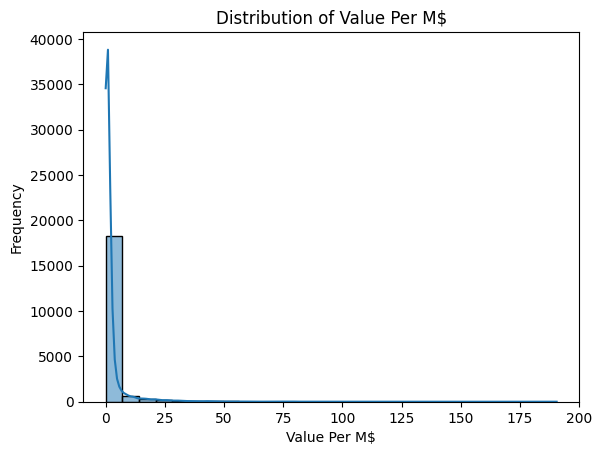

In [6]:
sns.histplot(df['Value Per M$'], bins=27, kde=True)
plt.title('Distribution of Value Per M$')
plt.xlabel('Value Per M$')
plt.ylabel('Frequency')

In [7]:
skewness_value = df['Value Per M$'].skew()
print(f"Skewness: {skewness_value}")

Skewness: 7.983215201865151


- The Histogram shows that most of the Values is less than 25M$. The values are right-skewed

- Compute correlation matrix for numerical features only, creating a heatmap to visualize relationships between those numerical features.

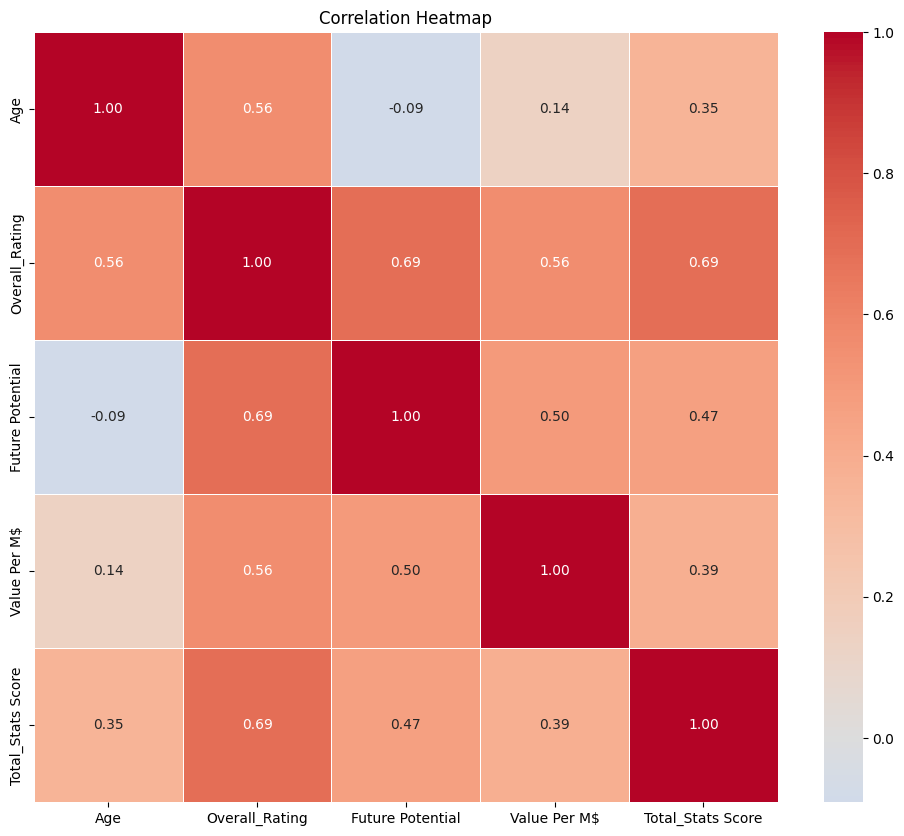

Top features related to Price:
Value Per M$         1.000000
Overall_Rating       0.560648
Future Potential     0.500964
Total_Stats Score    0.385062
Age                  0.142276
Name: Value Per M$, dtype: float64


In [8]:
corr = df.select_dtypes(include=np.number).corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5,annot_kws={"size": 10}, center=0)
plt.title('Correlation Heatmap')
plt.show()
print("Top features related to Price:")
print(corr['Value Per M$'].sort_values(ascending=False))

- Average Overall Rating per Position

In [9]:
avg_rating_per_position = df.groupby('Position')['Overall_Rating'].mean()
# avg_rating_per_position = avg_rating_per_position.sort_values(ascending=False)
print(avg_rating_per_position)

Position
CAM    63.679709
CB     63.544448
CDM    64.234168
CF     66.042857
CM     62.511767
GK     60.987288
LB     63.276794
LM     64.172009
LW     64.345979
LWB    64.043333
RB     62.863636
RF     75.000000
RM     63.907731
RW     63.718529
RWB    64.063973
ST     63.087505
SW     75.000000
Name: Overall_Rating, dtype: float64


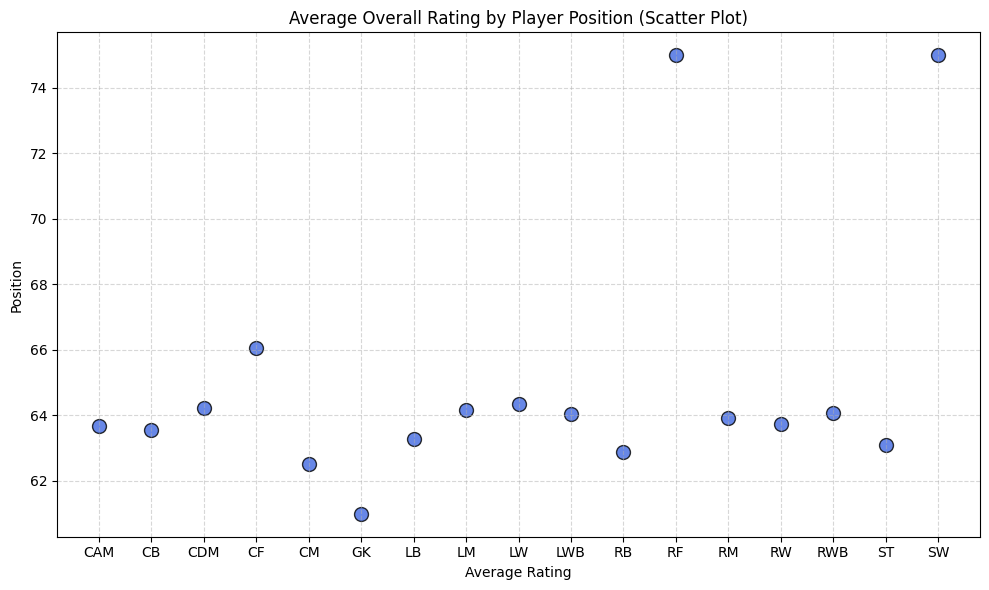

In [10]:
plt.figure(figsize=(10, 6))

plt.scatter(avg_rating_per_position.index, avg_rating_per_position.values, 
            color='royalblue', edgecolor='black', s=100, alpha=0.8)

plt.title('Average Overall Rating by Player Position (Scatter Plot)')
plt.xlabel('Average Rating')
plt.ylabel('Position')

plt.grid(axis='both', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

- The specialized offensive roles like SW and RF achieve the highest average ratings. In contrast, foundational roles like GK show the lowest averages, reflecting clear role-based performance differences across the pitch.

---

# Task 2: Data Preprocessing

In [11]:
print(df.duplicated().sum(), "Duplicates")
print(df.isnull().sum())

0 Duplicates
Name                 0
Country              0
Position             0
Age                  0
Overall_Rating       0
Future Potential     0
Team                 0
Value Per M$         0
Total_Stats Score    0
dtype: int64


- No duplicates neither null values!

- Drop non-useful category columns

In [12]:
df = df.drop(columns=['Name'])

## 1) Train / Test Split
- Spliting twice, one for linear regression (player market value) & another for logistic regression & classification (player performance)

- We also kept raw copies of the data before encoding and scaling. These raw datasets were later used in Assignment 3 to build unified Pipelines and apply Cross-Validation correctly without data leakage.

In [13]:
# Define features and target variable
x1 = df.drop(columns='Value Per M$')
y1 = df['Value Per M$']

x2 = df.drop(columns='Overall_Rating')
y2 = df['Overall_Rating']

x1_train, x1_test, y1_train, y1_test = train_test_split(
    x1, y1, test_size=0.2, random_state=1
)
x2_train, x2_test, y2_train, y2_test = train_test_split(
    x2, y2, test_size=0.2, random_state=1
)

x1_train_raw, x1_test_raw, y1_train_raw, y1_test_raw = train_test_split(
    x1, y1, test_size=0.2, random_state=1
)

x2_train_raw, x2_test_raw, y2_train_raw, y2_test_raw = train_test_split(
    x2, y2, test_size=0.2, random_state=1
)

print(f'First Train: {x1_train.shape}  | First Test: {x1_test.shape}')
print(f'Second Train: {x2_train.shape}  | Second Test: {x2_test.shape}')

First Train: (15733, 7)  | First Test: (3934, 7)
Second Train: (15733, 7)  | Second Test: (3934, 7)


## 2) Encode categorical columns

- We use One-Hot Encoding, cause we have nominal categorical features

In [14]:
cat_cols = ['Country', 'Position', 'Team']

def apply_ohe(train_df, test_df, columns):
    encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    
    train_encoded = encoder.fit_transform(train_df[columns])
    test_encoded = encoder.transform(test_df[columns])
    
    names = encoder.get_feature_names_out(columns)
    train_df_enc = pd.DataFrame(train_encoded, columns=names, index=train_df.index)
    test_df_enc = pd.DataFrame(test_encoded, columns=names, index=test_df.index)
    
    train_final = pd.concat([train_df.drop(columns=columns), train_df_enc], axis=1)
    test_final = pd.concat([test_df.drop(columns=columns), test_df_enc], axis=1)
    
    return train_final, test_final

x1_train, x1_test = apply_ohe(x1_train, x1_test, cat_cols)
x2_train, x2_test = apply_ohe(x2_train, x2_test, cat_cols)

## 3) Detect and handle outliers
- to be able to use minmax scaling without errors or wrong values.

- Outliers were removed based on the target variable (Value Per M$) only. This is because extreme values in the target can heavily distort regression performance metrics such as RMSE and R².

- However, we retained outliers in the feature space because they may still contain meaningful information about player characteristics and performance diversity.

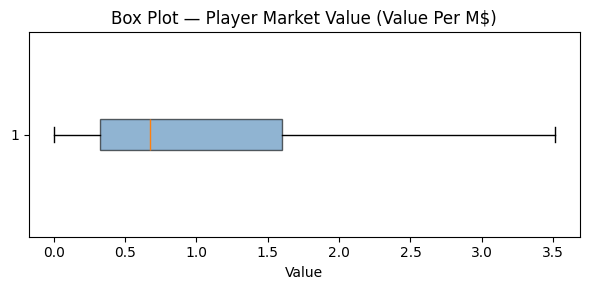

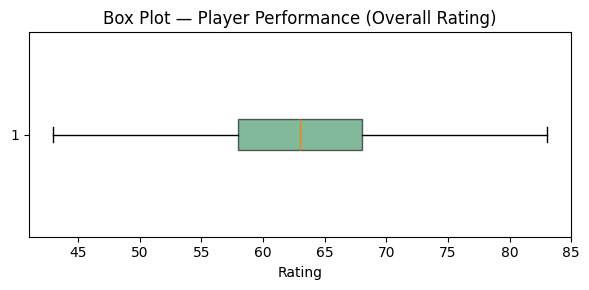

In [15]:
# Clip outliers for First Target (y1)
Q1_1 = y1_train.quantile(0.25)
Q3_1 = y1_train.quantile(0.75)
IQR1 = Q3_1 - Q1_1

lower1, upper1 = Q1_1 - 1.5 * IQR1, Q3_1 + 1.5 * IQR1
y1_train = y1_train.clip(lower=lower1, upper=upper1)

# Clip outliers for Second Target (y2)
Q1_2 = y2_train.quantile(0.25)
Q3_2 = y2_train.quantile(0.75)
IQR2 = Q3_2 - Q1_2

lower2, upper2 = Q1_2 - 1.5 * IQR2, Q3_2 + 1.5 * IQR2
y2_train = y2_train.clip(lower=lower2, upper=upper2)


# Visualization for y1 (Value Per M$)
plt.figure(figsize=(6, 3))
plt.boxplot(
    y1_train,
    vert=False,
    patch_artist=True,
    showfliers=False,
    boxprops=dict(facecolor='steelblue', alpha=0.6)
)
plt.title('Box Plot — Player Market Value (Value Per M$)')
plt.xlabel('Value')
plt.tight_layout()
plt.show()

# Visualization for y2 (Overall Rating)
plt.figure(figsize=(6, 3))
plt.boxplot(
    y2_train,
    vert=False,
    patch_artist=True,
    boxprops=dict(facecolor='seagreen', alpha=0.6)
)
plt.title('Box Plot — Player Performance (Overall Rating)')
plt.xlabel('Rating')
plt.tight_layout()
plt.show()

## 4) Scale numerical features
- Scaling the numerical data to avoid being biased by some features.

In [16]:
num_cols_reg = ['Age', 'Overall_Rating', 'Future Potential', 'Total_Stats Score']
num_cols_clf = ['Age', 'Value Per M$', 'Future Potential', 'Total_Stats Score']
# Scaling for First Model (x1)
x1_train_before_scaling = x1_train.copy()
x1_test_before_scaling = x1_test.copy()

scaler1 = StandardScaler()

# Fit on x1_train only and transform both
x1_train[num_cols_reg] = scaler1.fit_transform(x1_train[num_cols_reg])
x1_test[num_cols_reg] = scaler1.transform(x1_test[num_cols_reg])


# Scaling for Second Model (x2)
x2_train_before_scaling = x2_train.copy()
x2_test_before_scaling = x2_test.copy()

scaler2 = StandardScaler()

# Fit on x2_train only and transform both
x2_train[num_cols_clf] = scaler2.fit_transform(x2_train[num_cols_clf])
x2_test[num_cols_clf] = scaler2.transform(x2_test[num_cols_clf])

# Verify Scaling
print("x1_train range:", x1_train[num_cols_reg].min().min(), "to", x1_train[num_cols_reg].max().max())
print("x2_train range:", x2_train[num_cols_clf].min().min(), "to", x2_train[num_cols_clf].max().max())

x1_train range: -3.9452817691349575 to 4.483861926325417
x2_train range: -3.9452817691349575 to 25.486875092818394


---

# Task 3: Create Classification Target (Logistic Regression + Naïve Bayes)

- Classification target using equal-frequency binning
- we will identify the thresholds based on the distribution (Histogram and the describe method)

In [17]:
df['Overall_Rating'].describe()

count    19667.000000
mean        63.225403
std          7.812716
min         36.000000
25%         58.000000
50%         63.000000
75%         68.000000
max         91.000000
Name: Overall_Rating, dtype: float64

### Thresholds for each category

- We used pd.qcut() to divide the continuous Overall_Rating feature into four equal-frequency categories.
- Since the Overall_Rating distribution is right-skewed
- qcut is more suitable than cut because it creates balanced classes

In [18]:
# Create classification target using equal-frequency binning on training set only to avoid data leakage
y2_train_cat, bin_edges = pd.qcut(
    y2_train,
    q=4,
    labels=["Low", "Medium", "High", "Elite"],
    retbins=True
)

# Apply the same boundaries to the test set
y2_test_cat = pd.cut(
    y2_test,
    bins=[-np.inf, *bin_edges[1:-1], np.inf],
    labels=["Low", "Medium", "High", "Elite"]
)

In [19]:
print(f"Thresholds for each category: {bin_edges}")

Thresholds for each category: [43. 58. 63. 68. 83.]


### Threshold Justification

<Axes: xlabel='Overall_Rating', ylabel='Count'>

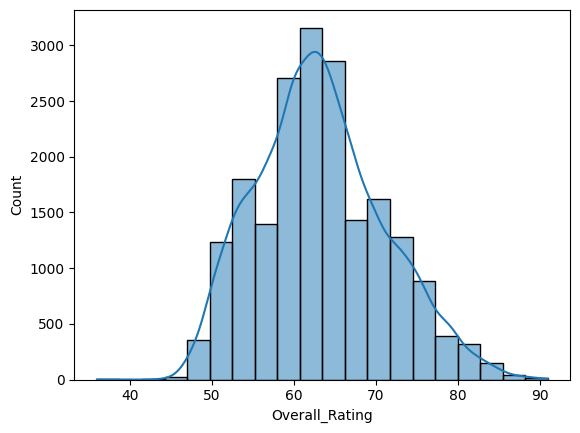

In [20]:
sns.histplot(df['Overall_Rating'], bins=20, kde=True)

### Number of players in each category

In [21]:
print("Train class distribution:")
print(y2_train_cat.value_counts())

print("\nTest class distribution:")
print(y2_test_cat.value_counts())

Train class distribution:
Overall_Rating
Low       4467
Medium    4062
Elite     3768
High      3436
Name: count, dtype: int64

Test class distribution:
Overall_Rating
Low       1101
Medium    1040
Elite      932
High       861
Name: count, dtype: int64


### Bar chart for the class distribution
- The dataset is balanced, Even though there are slight variations between the counts of each category, they all fall within a similar range.

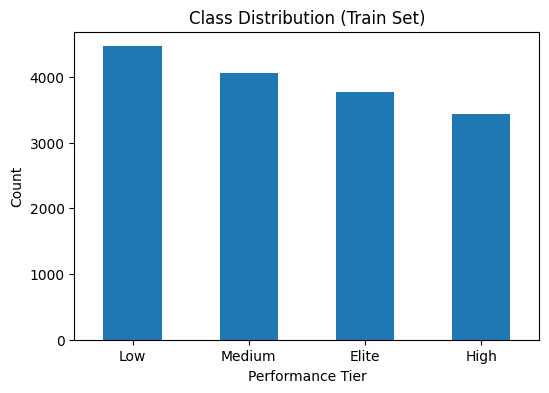

In [22]:
plt.figure(figsize=(6,4))
y2_train_cat.value_counts().plot(kind='bar')

plt.title("Class Distribution (Train Set)")
plt.xlabel("Performance Tier")
plt.ylabel("Count")

plt.xticks(rotation=0)
plt.show()

---

# Task 4 : Model 1 - Polynomial Regression

- Perform Linear Regression on the data.

In [23]:
model = LinearRegression()
model.fit(x1_train, y1_train)

y_train_pred = model.predict(x1_train)
y_test_pred = model.predict(x1_test)

def evaluate(y_true, y_pred, label):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    print(f"{label}:")
    print(f"MAE: {mae}")
    print(f"MSE: {mse}")
    print(f"RMSE: {rmse}")
    print(f"R2: {r2}")
    print("-----")

evaluate(y1_train, y_train_pred, "Train")
evaluate(y1_test, y_test_pred, "Test")

Train:
MAE: 0.3018457366491871
MSE: 0.15805361835643628
RMSE: 0.3975595783734009
R2: 0.8755949229670075
-----
Test:
MAE: 1.5652253026564464
MSE: 39.91088692361458
RMSE: 6.3175063849286754
R2: 0.1275698434205419
-----


- The results indicate that while the model fits the training data effectively, it does not generalize well. The huge increase in error metrics and the sharp decline in R2 on the test set point to overfitting, where the model captures noise or specific patterns in the training data rather than learning a robust underlying relationship.

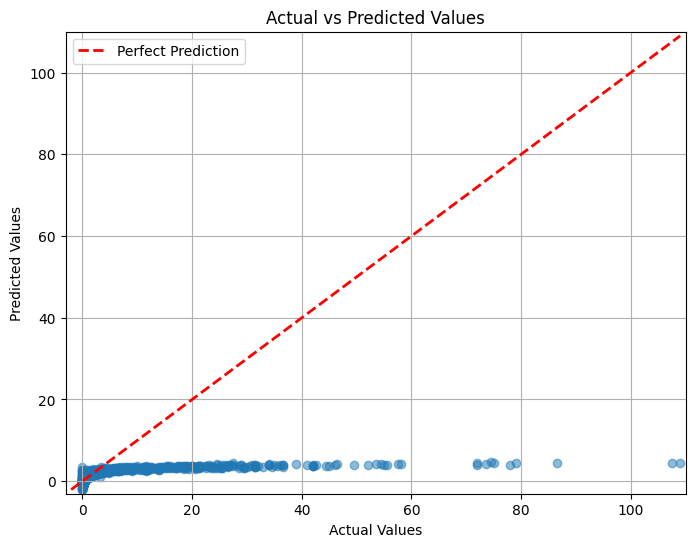

In [74]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y1_test,
    y_test_pred,
    alpha=0.5
)

min_val = min(y1_test.min(), y_test_pred.min())
max_val = max(y1_test.max(), y_test_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    'r--',
    linewidth=2,
    label='Perfect Prediction'
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")
plt.legend()
plt.grid(True)

plt.xlim(min_val - 1, max_val + 1)
plt.ylim(min_val - 1, max_val + 1)

plt.show()

- Perform Polynomial Regression with 4 degrees on the data.

In [24]:
cat_cols = x1_train.columns.difference(num_cols_reg)

In [25]:
degrees = [1, 2, 3, 4]
train_r2, test_r2 = [], []

for d in degrees:
    poly = PolynomialFeatures(degree=d, include_bias=False)

    # Only numerical features
    x1_train_num = poly.fit_transform(x1_train[num_cols_reg])
    x1_test_num = poly.transform(x1_test[num_cols_reg])

    # Convert back to DataFrame
    poly_cols = poly.get_feature_names_out(num_cols_reg)

    x1_train_poly = pd.DataFrame(x1_train_num, columns=poly_cols, index=x1_train.index)
    x1_test_poly = pd.DataFrame(x1_test_num, columns=poly_cols, index=x1_test.index)

    # Add categorical back
    x_train_final = pd.concat([x1_train_poly, x1_train[cat_cols]], axis=1)
    x_test_final = pd.concat([x1_test_poly, x1_test[cat_cols]], axis=1)

    model = LinearRegression()
    model.fit(x_train_final, y1_train)

    train_pred = model.predict(x_train_final)
    test_pred = model.predict(x_test_final)

    train_r2.append(r2_score(y1_train, train_pred))
    test_r2.append(r2_score(y1_test, test_pred))

    print(f"Degree {d}: Train R2={train_r2[-1]:.4f}, Test R2={test_r2[-1]:.4f}")

Degree 1: Train R2=0.8756, Test R2=0.1276
Degree 2: Train R2=0.8999, Test R2=0.1502
Degree 3: Train R2=0.9394, Test R2=0.1314
Degree 4: Train R2=0.9539, Test R2=0.1281


- As the polynomial degree increases from 1 to 4, the model fits the training data better, with R² steadily increasing from ~0.87 to ~0.95, showing higher flexibility.

- On the test data, performance improves up to degree 2 (from ~0.12 to 0.15), indicating that increasing model complexity helps capture non-linear relationships in the data.

- However, at degree 4, the test performance drops to ~0.12 again while training performance continues to improve, which indicates overfitting.

- Overall, degree 1 provides the best balance between bias and variance in this case.

- Scaling x_train_final, x_test_final with standardScaler, to improve regularization efficiency

In [26]:
scaler = StandardScaler()

x_train_final_scaled = scaler.fit_transform(x_train_final)

x_test_final_scaled = scaler.transform(x_test_final)

x_train_final_scaled = pd.DataFrame(
    x_train_final_scaled,
    columns=x_train_final.columns,
    index=x_train_final.index
)

x_test_final_scaled = pd.DataFrame(
    x_test_final_scaled,
    columns=x_test_final.columns,
    index=x_test_final.index
)

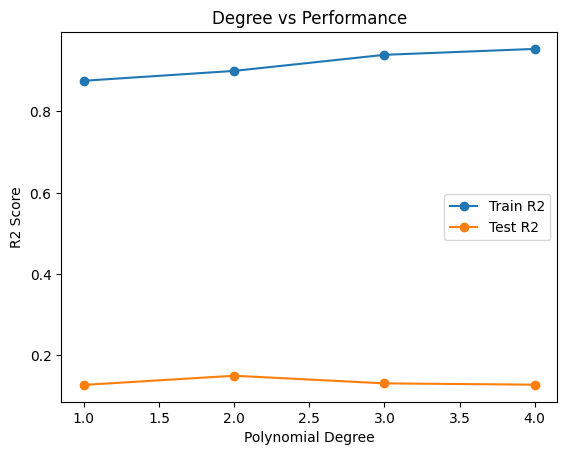

In [27]:
plt.plot(degrees, train_r2, marker='o', label="Train R2")
plt.plot(degrees, test_r2, marker='o', label="Test R2")

plt.xlabel("Polynomial Degree")
plt.ylabel("R2 Score")
plt.title("Degree vs Performance")
plt.legend()
plt.show()

- Overfitting is observed
- which degree gives the best generalization

In [28]:
gaps = []

for i in range(len(degrees)):
    gap = abs(train_r2[i] - test_r2[i])
    gaps.append(gap)

# Print all gaps
for d, tr, te, g in zip(degrees, train_r2, test_r2, gaps):
    print(f"Degree {d}: Train R2 = {tr:.4f}, Test R2 = {te:.4f}, Gap = {g:.4f}")

# Best degree = smallest gap
best_degree = degrees[np.argmin(gaps)]

print("\nBest Degree (based on smallest gap):", best_degree)

Degree 1: Train R2 = 0.8756, Test R2 = 0.1276, Gap = 0.7480
Degree 2: Train R2 = 0.8999, Test R2 = 0.1502, Gap = 0.7497
Degree 3: Train R2 = 0.9394, Test R2 = 0.1314, Gap = 0.8080
Degree 4: Train R2 = 0.9539, Test R2 = 0.1281, Gap = 0.8258

Best Degree (based on smallest gap): 1


- Before fitting the final model, polynomial features are generated for different degrees to capture non-linear relationships in the data. These transformed numerical features are then combined with the categorical features to build the final dataset.

- To evaluate model complexity, the difference between training and testing R2 (generalization gap) is calculated for each degree. This helps in identifying how well each model generalizes to unseen data.

- Based on the results, Degree 1 achieves the smallest gap, making it the best choice as it provides the most balanced performance between training and testing data.

In [29]:
poly = PolynomialFeatures(degree=best_degree, include_bias=False)

x_train_poly = poly.fit_transform(x1_train[num_cols_reg])
x_test_poly = poly.transform(x1_test[num_cols_reg])

poly_cols = poly.get_feature_names_out(num_cols_reg)

x_train_poly = pd.DataFrame(x_train_poly, columns=poly_cols, index=x1_train.index)
x_test_poly = pd.DataFrame(x_test_poly, columns=poly_cols, index=x1_test.index)

# add categorical features
x_train_final = pd.concat([x_train_poly, x1_train[cat_cols]], axis=1)
x_test_final = pd.concat([x_test_poly, x1_test[cat_cols]], axis=1)

In [30]:
alphas = np.logspace(-3, 3, 20)

train_rmse = []
test_rmse = []

best_rmse = float('inf')
best_alpha_ridge = None

for a in alphas:
    
    model = Ridge(alpha=a)
    model.fit(x_train_final, y1_train)

    train_pred = model.predict(x_train_final)
    test_pred = model.predict(x_test_final)

    train_error = np.sqrt(mean_squared_error(y1_train, train_pred))
    test_error = np.sqrt(mean_squared_error(y1_test, test_pred))

    train_rmse.append(train_error)
    test_rmse.append(test_error)

    print(f"Alpha: {a:.4f} | Train RMSE: {train_error:.4f} | Test RMSE: {test_error:.4f}")

    if test_error < best_rmse:
        best_rmse = test_error
        best_alpha_ridge = a

print("\nBest Ridge alpha:", best_alpha_ridge)

Alpha: 0.0010 | Train RMSE: 0.3976 | Test RMSE: 6.3175
Alpha: 0.0021 | Train RMSE: 0.3976 | Test RMSE: 6.3175
Alpha: 0.0043 | Train RMSE: 0.3976 | Test RMSE: 6.3175
Alpha: 0.0089 | Train RMSE: 0.3976 | Test RMSE: 6.3175
Alpha: 0.0183 | Train RMSE: 0.3976 | Test RMSE: 6.3176
Alpha: 0.0379 | Train RMSE: 0.3976 | Test RMSE: 6.3176
Alpha: 0.0785 | Train RMSE: 0.3976 | Test RMSE: 6.3178
Alpha: 0.1624 | Train RMSE: 0.3978 | Test RMSE: 6.3180
Alpha: 0.3360 | Train RMSE: 0.3983 | Test RMSE: 6.3185
Alpha: 0.6952 | Train RMSE: 0.3997 | Test RMSE: 6.3193
Alpha: 1.4384 | Train RMSE: 0.4028 | Test RMSE: 6.3204
Alpha: 2.9764 | Train RMSE: 0.4082 | Test RMSE: 6.3219
Alpha: 6.1585 | Train RMSE: 0.4161 | Test RMSE: 6.3234
Alpha: 12.7427 | Train RMSE: 0.4266 | Test RMSE: 6.3248
Alpha: 26.3665 | Train RMSE: 0.4389 | Test RMSE: 6.3264
Alpha: 54.5559 | Train RMSE: 0.4517 | Test RMSE: 6.3291
Alpha: 112.8838 | Train RMSE: 0.4640 | Test RMSE: 6.3341
Alpha: 233.5721 | Train RMSE: 0.4763 | Test RMSE: 6.3423
Alp

- After generating polynomial features, Ridge regression is applied as a regularization technique to reduce overfitting by penalizing large coefficients.

- A range of alpha values is tested to control the strength of regularization, and the model is evaluated using RMSE on both training and test sets.

- The best alpha is selected based on the lowest test RMSE, which in this case is 0.001, indicating that very weak regularization performs best for this dataset.

In [31]:
lasso_train_rmse = []
lasso_test_rmse = []

best_rmse = float('inf')
best_alpha_lasso = None

for a in alphas:
    
    model = Lasso(alpha=a, max_iter=2000)
    model.fit(x_train_final, y1_train)

    train_pred = model.predict(x_train_final)
    test_pred = model.predict(x_test_final)

    train_error = np.sqrt(mean_squared_error(y1_train, train_pred))
    test_error = np.sqrt(mean_squared_error(y1_test, test_pred))

    lasso_train_rmse.append(train_error)
    lasso_test_rmse.append(test_error)

    print(f"Alpha: {a:.4f} | Train RMSE: {train_error:.4f} | Test RMSE: {test_error:.4f}")

    if test_error < best_rmse:
        best_rmse = test_error
        best_alpha_lasso = a

print("\nBest Lasso alpha:", best_alpha_lasso)

Alpha: 0.0010 | Train RMSE: 0.4667 | Test RMSE: 6.3225
Alpha: 0.0021 | Train RMSE: 0.4779 | Test RMSE: 6.3294
Alpha: 0.0043 | Train RMSE: 0.4916 | Test RMSE: 6.3401
Alpha: 0.0089 | Train RMSE: 0.5003 | Test RMSE: 6.3499
Alpha: 0.0183 | Train RMSE: 0.5063 | Test RMSE: 6.3595
Alpha: 0.0379 | Train RMSE: 0.5146 | Test RMSE: 6.3750
Alpha: 0.0785 | Train RMSE: 0.5485 | Test RMSE: 6.4084
Alpha: 0.1624 | Train RMSE: 0.5729 | Test RMSE: 6.4520
Alpha: 0.3360 | Train RMSE: 0.6561 | Test RMSE: 6.5443
Alpha: 0.6952 | Train RMSE: 0.9182 | Test RMSE: 6.7404
Alpha: 1.4384 | Train RMSE: 1.1272 | Test RMSE: 6.8788
Alpha: 2.9764 | Train RMSE: 1.1272 | Test RMSE: 6.8788
Alpha: 6.1585 | Train RMSE: 1.1272 | Test RMSE: 6.8788
Alpha: 12.7427 | Train RMSE: 1.1272 | Test RMSE: 6.8788
Alpha: 26.3665 | Train RMSE: 1.1272 | Test RMSE: 6.8788
Alpha: 54.5559 | Train RMSE: 1.1272 | Test RMSE: 6.8788
Alpha: 112.8838 | Train RMSE: 1.1272 | Test RMSE: 6.8788
Alpha: 233.5721 | Train RMSE: 1.1272 | Test RMSE: 6.8788
Alp

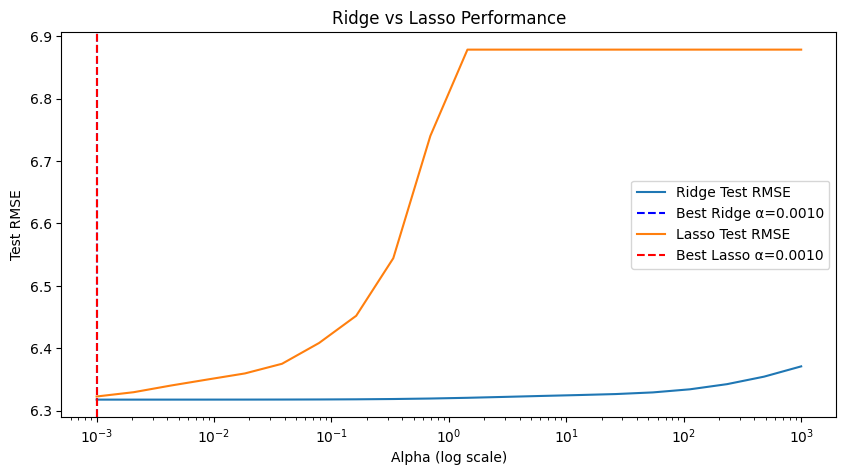

In [32]:
plt.figure(figsize=(10,5))

# Ridge
plt.plot(alphas, test_rmse, label="Ridge Test RMSE")
plt.axvline(best_alpha_ridge, linestyle="--", color="blue", label=f"Best Ridge α={best_alpha_ridge:.4f}")

# Lasso
plt.plot(alphas, lasso_test_rmse, label="Lasso Test RMSE")
plt.axvline(best_alpha_lasso, linestyle="--", color="red", label=f"Best Lasso α={best_alpha_lasso:.4f}")

plt.xscale("log")
plt.xlabel("Alpha (log scale)")
plt.ylabel("Test RMSE")
plt.title("Ridge vs Lasso Performance")
plt.legend()
plt.show()

### Ridge vs Lasso Comparison

Ridge regression performs better on this dataset compared to Lasso.

Reason:
The dataset contains many correlated features (especially after one-hot encoding and polynomial feature expansion). Ridge (L2 regularization) handles multicollinearity well by shrinking coefficients smoothly without removing features, which helps preserve useful information and improves generalization.

In contrast, Lasso (L1 regularization) performs feature selection by forcing some coefficients to zero. While this can be useful in sparse datasets, in this case it removes potentially important correlated features, leading to slightly worse performance on the test set.

### Did Lasso zero out any features
- Yes, Lasso eliminated several features, meaning it identified them as non-informative for prediction.

In [33]:
best_lasso = Lasso(alpha=best_alpha_lasso, max_iter=2000)
best_lasso.fit(x_train_final, y1_train)

zero_features = x_train_final.columns[best_lasso.coef_ == 0]

print("Number of zeroed features:", len(zero_features))
print("\nZeroed features:")
print(zero_features)

Number of zeroed features: 1120

Zeroed features:
Index(['Country_Albania', 'Country_Algeria', 'Country_Angola',
       'Country_Armenia', 'Country_Austria', 'Country_Azerbaijan',
       'Country_Belarus', 'Country_Belgium', 'Country_Benin',
       'Country_Bermuda',
       ...
       'Team_Zwickau', 'Team_Zürich', 'Team_Ñublense', 'Team_Örebro',
       'Team_Östersunds FK', 'Team_Ümraniyespor', 'Team_İstanbul Başakşehir',
       'Team_İstanbulspor', 'Team_ŁKS Łódź', 'Team_Śląsk Wrocław'],
      dtype='str', length=1120)


---
# Task 5 : Model 2 - Logistic Regression

We use Logistic Regression to classify FIFA players into four performance tiers **(Elite, High, Medium, Low)**. We start with a baseline model, then we tune the hyperparameters to find the best balance between training and testing accuracy.

#### Here we  initializes and trains a baseline Logistic Regression model using default parameters. We use a high number of iterations (max_iter=2000) to ensure the model converges on this dataset.

In [34]:
warnings.filterwarnings('ignore')

In [35]:
# Create and train the model
baseline_log_reg = LogisticRegression(max_iter=2000)

# Fit the model on training data
baseline_log_reg.fit(x2_train, y2_train_cat)

# Make predictions
y2_pred_baseline = baseline_log_reg.predict(x2_test)

# Classification Report
print("Baseline Logistic Regression Performance")
print(classification_report(y2_test_cat, y2_pred_baseline))

Baseline Logistic Regression Performance
              precision    recall  f1-score   support

       Elite       0.92      0.89      0.90       932
        High       0.76      0.76      0.76       861
         Low       0.89      0.89      0.89      1101
      Medium       0.77      0.79      0.78      1040

    accuracy                           0.84      3934
   macro avg       0.84      0.83      0.83      3934
weighted avg       0.84      0.84      0.84      3934



- The classification report shows an overall accuracy of 84%. The model performs very well on (Elite) and (Low) tiers, while showing slightly lower precision for (High) and (Medium) categories.

#### We generate a confusion matrix and visualize it using a heatmap. This helps us identify specific patterns of misclassification and see which player tiers are being confused with each other.

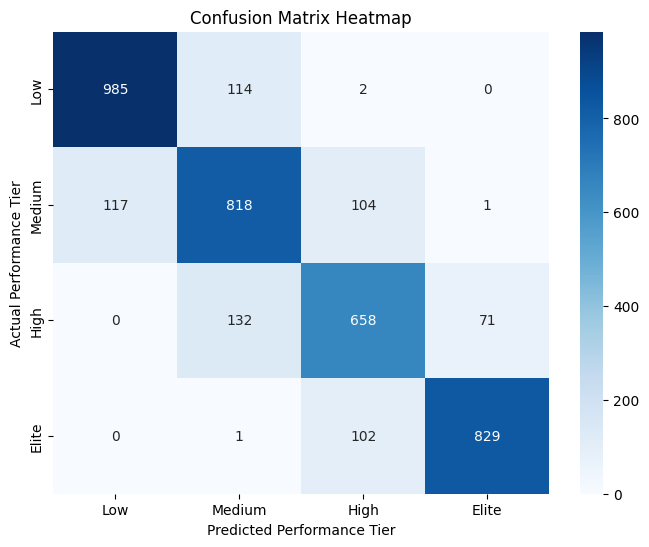

In [36]:
# Confusion matrix
cm = confusion_matrix(y2_test_cat, y2_pred_baseline, labels=["Low", "Medium", "High", "Elite"])

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=["Low", "Medium", "High", "Elite"], 
            yticklabels=["Low", "Medium", "High", "Elite"])
plt.xlabel('Predicted Performance Tier')
plt.ylabel('Actual Performance Tier')
plt.title('Confusion Matrix Heatmap')
plt.show()

- **The heatmap** shows a strong diagonal, indicating that the majority of predictions are correct. Most errors occur between adjacent tiers, such as (Medium) being misclassified as (High), which is expected due to the similarity in player statistics.

#### We perform a hyperparameter sweep over different values of (C) to find the optimal regularization strength. We plot both training and testing accuracies to identify the point where the model achieves the best generalization without overfitting

C= 0.001 | Train Acc=0.7491 | Test Acc=0.7410
C= 0.002 | Train Acc=0.7738 | Test Acc=0.7666
C= 0.004 | Train Acc=0.7922 | Test Acc=0.7842
C= 0.009 | Train Acc=0.8035 | Test Acc=0.7923
C= 0.018 | Train Acc=0.8115 | Test Acc=0.8007
C= 0.038 | Train Acc=0.8223 | Test Acc=0.8086
C= 0.078 | Train Acc=0.8368 | Test Acc=0.8124
C= 0.162 | Train Acc=0.8508 | Test Acc=0.8188
C= 0.336 | Train Acc=0.8658 | Test Acc=0.8228
C= 0.695 | Train Acc=0.8818 | Test Acc=0.8312
C= 1.438 | Train Acc=0.8972 | Test Acc=0.8376
C= 2.976 | Train Acc=0.9087 | Test Acc=0.8437
C= 6.158 | Train Acc=0.9189 | Test Acc=0.8493
C=12.743 | Train Acc=0.9279 | Test Acc=0.8523
C=26.367 | Train Acc=0.9356 | Test Acc=0.8528
C=54.556 | Train Acc=0.9401 | Test Acc=0.8577
C=112.884 | Train Acc=0.9429 | Test Acc=0.8554
C=233.572 | Train Acc=0.9452 | Test Acc=0.8615
C=483.293 | Train Acc=0.9462 | Test Acc=0.8571
C=1000.000 | Train Acc=0.9463 | Test Acc=0.8587


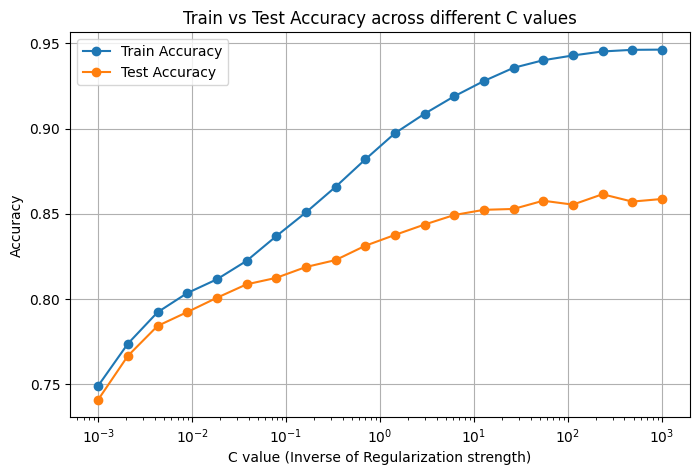


Best C value based on Test Accuracy is: 233.57214690901213


In [37]:
# Create a range of C values (from 0.001 to 1000)
c_values = np.logspace(-3, 3, 20)

train_accuracies = []
test_accuracies = []

# Loop through each C value
for c in c_values:
    
    model = LogisticRegression(C=c, max_iter=2000)
    model.fit(x2_train, y2_train_cat)
    
    # Calculate accuracy for both sets
    train_acc = accuracy_score(y2_train_cat, model.predict(x2_train))
    test_acc = accuracy_score(y2_test_cat, model.predict(x2_test))
    
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)
    print(f"C={c:6.3f} | Train Acc={train_acc:.4f} | Test Acc={test_acc:.4f}")

#  Plot the learning curve
plt.figure(figsize=(8, 5))
plt.plot(c_values, train_accuracies, label='Train Accuracy', marker='o')
plt.plot(c_values, test_accuracies, label='Test Accuracy', marker='o')
plt.xscale('log') 
plt.xlabel('C value (Inverse of Regularization strength)')
plt.ylabel('Accuracy')
plt.title('Train vs Test Accuracy across different C values')
plt.legend()
plt.grid(True)
plt.show()

#  Get the best C
best_c_index = np.argmax(test_accuracies)
best_c = c_values[best_c_index]
print(f"\nBest C value based on Test Accuracy is: {best_c}")

- The results show that as (C) increases, training accuracy keeps improving, while test accuracy reaches its best value around C = 233.572 before stabilizing. This indicates that C = 233.572 gives the best balance between fitting the training data and generalization.

#### We compare two types of regularization: L1 (Lasso) and L2 (Ridge), using the best (C) value found previously. We aim to determine which penalty provides better generalization for our classification problem.

In [38]:
# Train L1 (Lasso)  Uses saga
model_l1 = LogisticRegression(penalty='l1', C=best_c, solver='saga', max_iter=2000)
model_l1.fit(x2_train, y2_train_cat)
acc_l1 = accuracy_score(y2_test_cat, model_l1.predict(x2_test))

# Train L2 (Ridge)  Uses lbfgs
model_l2 = LogisticRegression(penalty='l2', C=best_c, solver='lbfgs', max_iter=2000)
model_l2.fit(x2_train, y2_train_cat)
acc_l2 = accuracy_score(y2_test_cat, model_l2.predict(x2_test))

# display results
print(f"Accuracy with L1 penalty (saga solver): {acc_l1:.4f}")
print(f"Accuracy with L2 penalty (lbfgs solver): {acc_l2:.4f}")


if acc_l1 > acc_l2:
    print("\nL1 Regularization performs better.")
elif acc_l2 > acc_l1:
    print("\nL2 Regularization performs better.")
else:
    print("\nBoth regularizations perform equally well.")

Accuracy with L1 penalty (saga solver): 0.8457
Accuracy with L2 penalty (lbfgs solver): 0.8615

L2 Regularization performs better.


- The output show that both L1 and L2 perform similarly, but L2 achieves slightly higher accuracy. This suggests that keeping all features with smooth regularization works better for this dataset than removing some features using L1 regularization.

#### We analyze the detailed performance of L1 and L2 using classification reports. We also see the Feature Selection capability of L1 by counting how many features were completely removed from the model.

In [39]:
# Print detailed classification reports for both models
print("\nL1 Regularization (Lasso) Report:")
print(classification_report(y2_test_cat, model_l1.predict(x2_test)))

print("\nL2 Regularization (Ridge) Report:")
print(classification_report(y2_test_cat, model_l2.predict(x2_test)))

# Count the number of features removed by L1 (Zeroed out coefficients)
coef_l1 = model_l1.coef_
zero_count = np.sum(coef_l1 == 0)

print("-" * 30)
print(f"Number of features zeroed out by L1: {zero_count}")
print("-" * 30)


L1 Regularization (Lasso) Report:
              precision    recall  f1-score   support

       Elite       0.91      0.91      0.91       932
        High       0.79      0.78      0.79       861
         Low       0.89      0.90      0.89      1101
      Medium       0.79      0.78      0.79      1040

    accuracy                           0.85      3934
   macro avg       0.84      0.84      0.84      3934
weighted avg       0.85      0.85      0.85      3934


L2 Regularization (Ridge) Report:
              precision    recall  f1-score   support

       Elite       0.91      0.92      0.91       932
        High       0.81      0.80      0.81       861
         Low       0.89      0.91      0.90      1101
      Medium       0.82      0.81      0.81      1040

    accuracy                           0.86      3934
   macro avg       0.86      0.86      0.86      3934
weighted avg       0.86      0.86      0.86      3934

------------------------------
Number of features zeroed out

- The results show that both models achieve very similar overall accuracy (~85% Vs 86%), with L2 performing slightly better. However, L1 (Lasso) still provides an important advantage by simplifying the model. It managed to achieve comparable performance while completely removing 396 features, which helps create a more compact and interpretable model by focusing only on the most important variables.

---
# Task 6 : Model 3 - Naïve Bayes Classification

Naive Bayes is a classification algorithm based on probability and Bayes’ Theorem. 
It assumes that all features are independent given the class.

In this task, we apply different Naive Bayes variants to classify players into performance tiers. 
Each variant is tested based on the type of features used, and the models are evaluated using standard classification metrics and confusion matrices.

**The evaluation metrics** (Accuracy, Precision, Recall, and F1-score) were obtained using the classification_report function from sklearn.

### 1. Gaussian Naive Bayes (GaussianNB):

- The selected features were chosen based on their relevance to the target variable and their compatibility with the Gaussian Naive Bayes model.

- Only numerical and continuous features were used, as GaussianNB assumes normally distributed inputs. Features such as "Age", "Future Potential", and "Total_Stats Score" provide meaningful information about player performance.

- This selection helped reduce noise and improve model performance.

###  Gaussian Naive Bayes (GaussianNB) without scaling

 ====== GaussianNB (Without Scaling) ======= 
Accuracy: 0.7709710218607015
              precision    recall  f1-score   support

       Elite       0.96      0.65      0.78       932
        High       0.59      0.74      0.66       861
         Low       0.89      0.89      0.89      1101
      Medium       0.72      0.77      0.75      1040

    accuracy                           0.77      3934
   macro avg       0.79      0.77      0.77      3934
weighted avg       0.80      0.77      0.77      3934



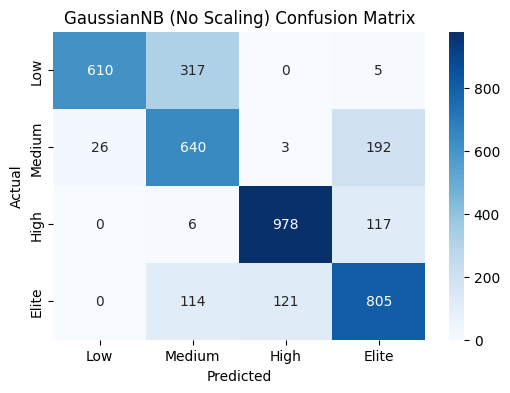

In [40]:
# Without scaling
X_train_g_raw = x2_train_before_scaling[num_cols_clf]
X_test_g_raw = x2_test_before_scaling[num_cols_clf]

gnb_raw = GaussianNB()
gnb_raw.fit(X_train_g_raw, y2_train_cat)

pred_g_raw = gnb_raw.predict(X_test_g_raw)

acc_raw = accuracy_score(y2_test_cat, pred_g_raw)

print(" ====== GaussianNB (Without Scaling) ======= ")
print("Accuracy:", acc_raw)
print(classification_report(y2_test_cat, pred_g_raw))

cm_g_raw = confusion_matrix(y2_test_cat, pred_g_raw)

plt.figure(figsize=(6,4))
sns.heatmap(cm_g_raw, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Low","Medium","High","Elite"],
            yticklabels=["Low","Medium","High","Elite"])
plt.title("GaussianNB (No Scaling) Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

The model achieved an accuracy of 77%, showing reasonable overall performance. It performs well in predicting the "Low" class, while some confusion appears between "High", "Medium", and "Elite" classes. The confusion matrix indicates that most predictions are correct, but errors mainly occur between classes with similar feature patterns, which may result from overlapping distributions in the dataset.

###   Gaussian Naive Bayes (GaussianNB) with scaling


===== GaussianNB (With Scaling) =====
Accuracy: 0.7704626334519573
              precision    recall  f1-score   support

       Elite       0.96      0.65      0.78       932
        High       0.59      0.74      0.66       861
         Low       0.89      0.89      0.89      1101
      Medium       0.72      0.77      0.75      1040

    accuracy                           0.77      3934
   macro avg       0.79      0.76      0.77      3934
weighted avg       0.80      0.77      0.77      3934



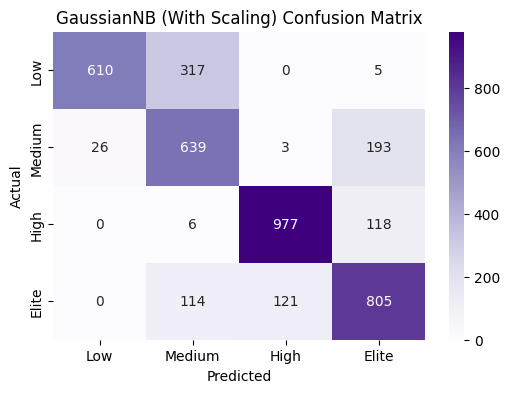

In [41]:
#  WITH scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_g_raw)
X_test_scaled = scaler.transform(X_test_g_raw)

gnb_scaled = GaussianNB()
gnb_scaled.fit(X_train_scaled, y2_train_cat)

pred_g_scaled = gnb_scaled.predict(X_test_scaled)

acc_scaled = accuracy_score(y2_test_cat, pred_g_scaled)

print("\n===== GaussianNB (With Scaling) =====")
print("Accuracy:", acc_scaled)
print(classification_report(y2_test_cat, pred_g_scaled))

cm_g_scaled = confusion_matrix(y2_test_cat, pred_g_scaled)

plt.figure(figsize=(6,4))
sns.heatmap(cm_g_scaled, annot=True, fmt='d', cmap='Purples',
            xticklabels=["Low","Medium","High","Elite"],
            yticklabels=["Low","Medium","High","Elite"])
plt.title("GaussianNB (With Scaling) Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

- The model achieved an accuracy of 77%, which is nearly identical to the result without scaling.

- Performance remains strong for the "Low" class, while some confusion still appears between "High", "Medium", and "Elite" classes. The confusion matrix shows mostly correct predictions with expected errors between similar classes.

- Scaling did not improve performance, suggesting that GaussianNB is relatively insensitive to feature scaling on this dataset.

 Scaling Comparison Result
----------------------------------------
WITHOUT Scaling -> Accuracy = 0.7710
WITH Scaling    -> Accuracy = 0.7705
Difference (Scaled - Raw): -0.000508

 Scaling has NO significant effect on performance.


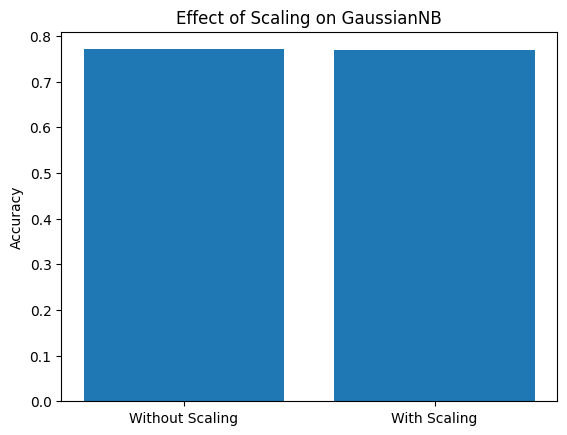

In [42]:
#  Scaling Comparison

print(" Scaling Comparison Result")
print("-" * 40)

print(f"WITHOUT Scaling -> Accuracy = {acc_raw:.4f}")
print(f"WITH Scaling    -> Accuracy = {acc_scaled:.4f}")
diff = acc_scaled - acc_raw
print(f"Difference (Scaled - Raw): {diff:.6f}")

if abs(diff) < 0.01:
    print("\n Scaling has NO significant effect on performance.")
elif diff > 0:
    print("\n Scaling slightly improved performance.")
else:
    print("\n Scaling slightly reduced performance.")


labels = ['Without Scaling', 'With Scaling']
values = [acc_raw, acc_scaled]

plt.figure()
plt.bar(labels, values)
plt.title("Effect of Scaling on GaussianNB")
plt.ylabel("Accuracy")
plt.show()

### The comparison between GaussianNB with and without scaling 
It shows that the accuracy remains excatly the same (77.10% vs 77.05%).

This indicates that feature scaling has no significant impact on the model’s performance. This is expected because Gaussian Naive Bayes relies on the statistical distribution of the data (mean and variance) rather than the absolute values of the features.

Therefore, scaling does not change the underlying distribution, which explains the nearly identical results.

### 2. Bernoulli Naive Bayes (BernoulliNB):

This model is suitable for binary features. It was applied on the dataset after one-hot encoding, where categorical variables were transformed into binary format.


===== BernoulliNB =====
Accuracy: 0.672089476359939
              precision    recall  f1-score   support

       Elite       0.85      0.79      0.82       932
        High       0.52      0.55      0.54       861
         Low       0.77      0.80      0.79      1101
      Medium       0.54      0.53      0.53      1040

    accuracy                           0.67      3934
   macro avg       0.67      0.67      0.67      3934
weighted avg       0.67      0.67      0.67      3934



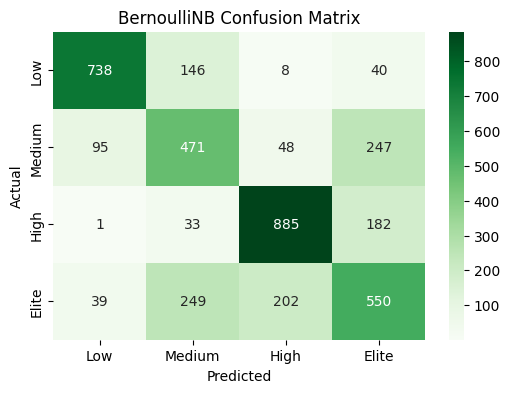

In [43]:
# 2) BernoulliNB (OHE Features)

bnb = BernoulliNB()
bnb.fit(x2_train, y2_train_cat)

pred_b = bnb.predict(x2_test)

print("\n===== BernoulliNB =====")
print("Accuracy:", accuracy_score(y2_test_cat, pred_b))
print(classification_report(y2_test_cat, pred_b))

cm_b = confusion_matrix(y2_test_cat, pred_b)

plt.figure(figsize=(6,4))
sns.heatmap(cm_b, annot=True, fmt='d', cmap='Greens',
            xticklabels=["Low","Medium","High","Elite"],
            yticklabels=["Low","Medium","High","Elite"])
plt.title("BernoulliNB Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

- BernoulliNB achieved **lower performance (~67% accuracy)** compared to GaussianNB.

- The model performs better on the "Low" and "Elite" classes, but struggles more with "Medium" and "High". The confusion matrix shows noticeable misclassification between these classes.

- This behavior is expected because BernoulliNB is mainly designed for binary features, while the dataset still contains continuous numerical features alongside the encoded categorical data.

### 3. Complement Naive Bayes (ComplementNB):

This model is designed for imbalanced datasets and requires non-negative input values. Therefore, the data was shifted to remove negative values before training.


===== ComplementNB =====
Accuracy: 0.5388917132689375
              precision    recall  f1-score   support

       Elite       0.63      0.78      0.70       932
        High       0.39      0.30      0.34       861
         Low       0.58      0.71      0.64      1101
      Medium       0.46      0.33      0.39      1040

    accuracy                           0.54      3934
   macro avg       0.51      0.53      0.52      3934
weighted avg       0.52      0.54      0.52      3934



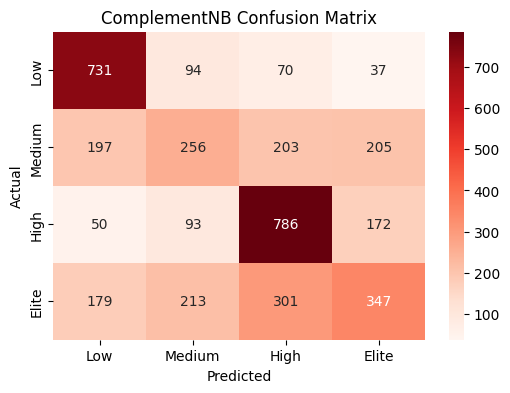

In [44]:
# 3) ComplementNB (Non-negative Data)

# Shift to remove negative values
X_train_shifted = x2_train - x2_train.min()
X_test_shifted = x2_test - x2_train.min()

cnb = ComplementNB()
cnb.fit(X_train_shifted, y2_train_cat)

pred_c = cnb.predict(X_test_shifted)

print("\n===== ComplementNB =====")
print("Accuracy:", accuracy_score(y2_test_cat, pred_c))
print(classification_report(y2_test_cat, pred_c))

cm_c = confusion_matrix(y2_test_cat, pred_c)

plt.figure(figsize=(6,4))
sns.heatmap(cm_c, annot=True, fmt='d', cmap='Reds',
            xticklabels=["Low","Medium","High","Elite"],
            yticklabels=["Low","Medium","High","Elite"])
plt.title("ComplementNB Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

- ComplementNB achieved the lowest performance (~54% accuracy) among all Naive Bayes models.

- The model performs reasonably on the "Low" and "Elite" classes, but struggles significantly with "Medium" and "High", where the confusion matrix shows substantial misclassification.

- This behavior is expected because ComplementNB is mainly designed for count-based and imbalanced text-like data, while the dataset contains continuous numerical features, making it less suitable even after shifting the data to remove negative values.

### **After evaluating all three Naïve Bayes variants :**

The most appropriate Naïve Bayes variant for this dataset is **Gaussian Naive Bayes**. This is because the dataset mainly contains continuous numerical features such as Age, Future Potential, and Total_Stats Score.

GaussianNB assumes that features follow a normal (Gaussian) distribution, which makes it suitable for handling continuous data. On the other hand, BernoulliNB is designed for binary features (0/1), and ComplementNB is more suitable for discrete count-based data like text.

Based on both the nature of the features and the experimental results, GaussianNB achieved better performance compared to the other variants. Therefore, it is the most suitable choice for this dataset.

---
# Task 7 : Model Evaluation with Cross-Validation

We applied Cross-Validation techniques to obtain more reliable and robust estimates of model performance. Instead of relying on a single train/test split, we evaluated models across multiple data subsets to assess both accuracy and stability.

## Regression Evaluation (K-Fold Cross-Validation)

A 5-Fold Cross-Validation approach was used to evaluate the best Polynomial Ridge Regression model selected in Task 4.

To ensure proper preprocessing and avoid data leakage, a Pipeline was constructed to include:
- StandardScaler for feature scaling
- PolynomialFeatures for feature expansion
- Ridge Regression for regularized learning

The model was evaluated using Root Mean Squared Error (RMSE). Since scikit-learn returns negative values for loss-based metrics, the scores were negated to obtain actual RMSE values.

A bar chart was plotted to visualize RMSE across folds, along with a mean RMSE line to assess consistency and model stability.

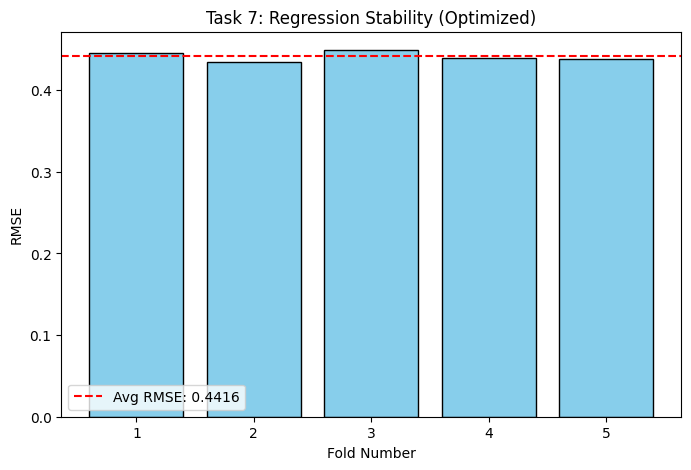

Individual Fold RMSE Scores: [0.44588126 0.43492525 0.44925959 0.43945151 0.43827155]
Mean RMSE: 0.4416
RMSE Standard Deviation: 0.0052


In [45]:
# Setup preprocessor: Poly & Scale for numerical, Passthrough for others
preprocessor_reg = ColumnTransformer([
    ('poly_and_scale', Pipeline([
        ('poly', PolynomialFeatures(degree=best_degree, include_bias=False)),
        ('scaler', StandardScaler())
    ]), num_cols_reg)
], remainder='passthrough')

# Final Regression Pipeline
best_reg_pipeline = Pipeline([
    ('preprocessor', preprocessor_reg),
    ('ridge', Ridge(alpha=best_alpha_ridge))
])

# Run 5-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_rmse_scores = -cross_val_score(best_reg_pipeline, x1_train, y1_train, cv=kf, scoring='neg_root_mean_squared_error')

# Plot stability results
plt.figure(figsize=(8, 5))
plt.bar(range(1, 6), cv_rmse_scores, color='skyblue', edgecolor='black')
plt.axhline(y=cv_rmse_scores.mean(), color='red', linestyle='--', label=f'Avg RMSE: {cv_rmse_scores.mean():.4f}')
plt.title("Task 7: Regression Stability (Optimized)")
plt.xlabel("Fold Number")
plt.ylabel("RMSE")
plt.legend()
plt.show()

# Report Final Metrics (Mean, Std, and Individual)
print(f"Individual Fold RMSE Scores: {cv_rmse_scores}")
print(f"Mean RMSE: {cv_rmse_scores.mean():.4f}")
print(f"RMSE Standard Deviation: {cv_rmse_scores.std():.4f}")

**Metric:**
Root Mean Squared Error (RMSE) evaluated using 5-fold cross-validation.

**Individual Fold Scores:**
The model demonstrated strong consistency, with RMSE values ranging from approximately **~0.43 to ~0.45** across the folds.

**Average Performance:**
- **Mean RMSE:** 0.4416
- **Standard Deviation:** 0.0052

**Stability Analysis:**
The low variance and small standard deviation indicate that the model is robust and stable.
Performance remains consistent across different data splits, showing that the model does not depend on a specific train/test partition.

**Conclusion:**
The optimized pipeline (**Polynomial Features + Ridge Regression**) achieves a good balance between predictive accuracy and stability, effectively reducing overfitting while maintaining reliable performance.

## Classification Evaluation (Stratified K-Fold Cross-Validation)

For classification, we used Stratified 5-Fold Cross-Validation to compare two models:
- Logistic Regression
- Gaussian Naive Bayes

Stratification was applied to ensure that class distributions (Low, Mid, High, Elite) remained balanced in each fold.

To prevent data leakage, Pipelines were used so that scaling is applied independently within each fold.

Model performance was evaluated using accuracy. A grouped bar chart was created to compare fold-by-fold accuracy between the two models, providing insights into both performance and stability.

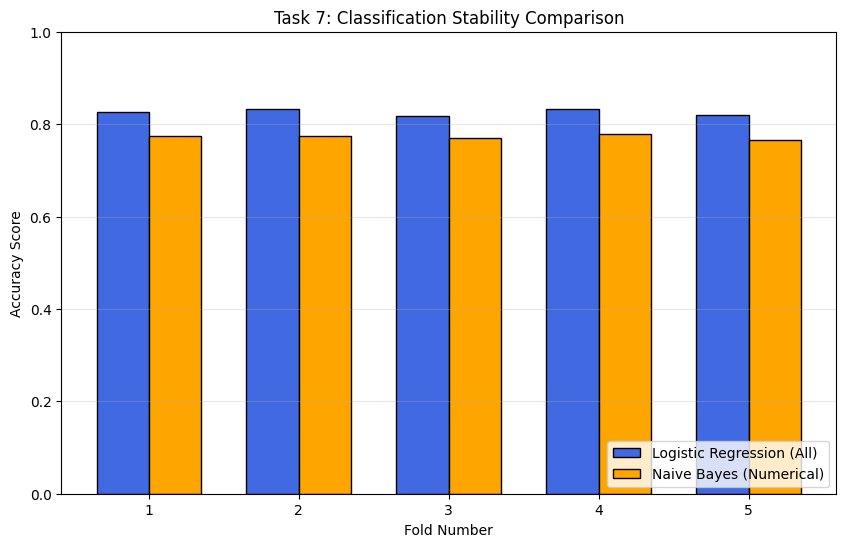

Logistic Regression - Mean Accuracy: 0.8253, Std Dev: 0.0065
Naive Bayes - Mean Accuracy: 0.7723, Std Dev: 0.0047


In [46]:
# Filter numerical features only for Naive Bayes (prevents noise)
preprocessor_nb = ColumnTransformer([
    ('numeric_only', StandardScaler(), num_cols_clf)
], remainder='drop')

# Setup Pipelines for both models
log_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(C=best_c, max_iter=2000))
])

nb_pipeline = Pipeline([
    ('preprocessor', preprocessor_nb),
    ('model', GaussianNB())
])

# Use Stratified K-Fold to maintain class balance
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Calculate cross-validation scores
log_scores = cross_val_score(log_pipeline, x2_train_before_scaling, y2_train_cat, cv=skf)
nb_scores = cross_val_score(nb_pipeline, x2_train_before_scaling, y2_train_cat, cv=skf)

# Plot performance comparison
x = np.arange(1, 6)
width = 0.35
plt.figure(figsize=(10, 6))

plt.bar(x - width/2, log_scores, width, label='Logistic Regression (All)', color='royalblue', edgecolor='black')
plt.bar(x + width/2, nb_scores, width, label='Naive Bayes (Numerical)', color='orange', edgecolor='black')

plt.xlabel('Fold Number')
plt.ylabel('Accuracy Score')
plt.title('Task 7: Classification Stability Comparison')
plt.xticks(x)
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.grid(axis='y', alpha=0.3)
plt.show()

# Report Final Metrics (Mean & Std)
print(f"Logistic Regression - Mean Accuracy: {log_scores.mean():.4f}, Std Dev: {log_scores.std():.4f}")
print(f"Naive Bayes - Mean Accuracy: {nb_scores.mean():.4f}, Std Dev: {nb_scores.std():.4f}")

- **Metric:** Accuracy Score evaluated across 5 stratified folds.

- **Performance Comparison:**

1. Logistic Regression (All Features): Maintains a consistent lead with an accuracy of ~82% across all folds.

2. Naive Bayes (Numerical Only): Shows strong competitive performance with an accuracy of ~77%.

- **Key Observations:**

1. High Stability: Both models exhibit very low variance between folds, proving that the results are reliable and not due to a lucky data split.

2. Feature Optimization: Restricting Naive Bayes to numerical features improves its reliability, but it still remains behind Logistic Regression in accuracy.

- **Conclusion:** Logistic Regression is the best-performing model in this comparison, while Naive Bayes remains a stable and simpler alternative with slightly lower accuracy.

---
# Task 8 : Analysis and Discussion

## A) Model Comparison

### Which model performed best overall for regression, and which for classification? Justify briefly.
- **Regression:** The Polynomial Ridge Regression model performed the best. A polynomial degree of 1 was selected because it gave the best balance between training and testing performance with the smallest generalization gap. Ridge regularization also improved generalization compared to Lasso. Finally, 5-fold cross-validation confirmed its stability with a consistent Mean RMSE of 0.4416 and low variance across folds.

- **Classification:** Logistic Regression was the best model. It achieved the highest performance overall and remained stable across stratified 5-fold cross-validation with a mean accuracy of around 0.82. It also outperformed the optimized Gaussian Naive Bayes model, which achieved about 0.77 accuracy, making Logistic Regression the most reliable choice for this task.

### Is classification easier or harder than regression on this dataset? Why?

- Classification is generally easier on this dataset.

- For the classification task, the continuous Overall_Rating variable was converted into four broad categories: "Low", "Medium", "High", and "Elite", which reduces the complexity of the prediction problem.

- Predicting a general class is simpler than regression, which requires estimating the exact continuous value of Value Per M$.

- In regression, the model must capture fine-grained numerical differences, while classification only requires assigning each player to a broader category, making it less sensitive to small prediction errors.

## B) Regularization Analysis

### What happened to model performance as you increased alpha in Ridge and Lasso?

- As the **alpha** value (regularization strength) increased, the model performance consistently worsened for both Ridge and Lasso.

- For Ridge regression, the Test RMSE gradually increased from about 6.3175 at alpha = 0.001 to around 6.3708 at higher alpha values (~1000), showing a steady decline in performance.

- For Lasso regression, the Test RMSE also increased as alpha grew, starting from lower values at small alpha and reaching its worst performance at large alpha values, indicating stronger degradation compared to Ridge.

- This behavior shows that increasing alpha makes the model more constrained, leading to underfitting, since the coefficients are overly penalized and the model loses its ability to capture patterns in the data.

### Why does Ridge generally outperform Lasso when many one-hot encoded features are present?

- **Ridge (L2 regularization)** handles many correlated and redundant features well by shrinking coefficients smoothly without removing them, which helps preserve useful information across one-hot encoded and polynomial features.

- **Lasso (L1 regularization)**, performs strong feature selection by forcing some coefficients to become exactly zero, which leads to a much sparser model.

- In this dataset, **Lasso** removed a large number of features, including some correlated ones coming from one-hot encoding. This caused a loss of useful information, which slightly reduced its generalization performance compared to Ridge.

---
# Assignment 3

### Imports

In [47]:
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score, KFold
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.svm import SVC
import json

### Instance-Based algorithm (KNN)

KNN was selected because the FIFA dataset contains numerical player attributes such as Age, Future Potential, and Total_Stats Score, where similar players naturally tend to have comparable market values.

Since the dataset was scaled during preprocessing, distance calculations became more reliable, making KNN suitable for capturing local patterns and similarities between players.

- KNN (Classification)

In [48]:
# Baseline Model
knn_clf_baseline = KNeighborsClassifier(n_neighbors=1)

knn_clf_baseline.fit(x2_train, y2_train_cat)

y_pred_base_clf = knn_clf_baseline.predict(x2_test)

baseline_acc = accuracy_score(y2_test_cat, y_pred_base_clf)

print("\n--- Baseline ---")
print("Accuracy:", baseline_acc)
print(classification_report(y2_test_cat, y_pred_base_clf))


# Grid Search
param_grid_clf = {
    "n_neighbors": range(3, 30, 2),
    "metric": ["euclidean", "manhattan"]
}

kfold = KFold(n_splits=5, shuffle=True, random_state=42)
grid_knn_clf = GridSearchCV(
    estimator = KNeighborsClassifier(),
    param_grid = param_grid_clf,
    cv = kfold,
    scoring = 'accuracy',
    n_jobs = -1,
)

grid_knn_clf.fit(x2_train, y2_train_cat)

best_knn_clf = grid_knn_clf.best_estimator_

print("\n--- Best Parameters (Classification) ---")
print(grid_knn_clf.best_params_)


# Evaluation
y_pred_knn_clf = best_knn_clf.predict(x2_test)

tuned_acc = accuracy_score(y2_test_cat, y_pred_knn_clf)

print("\n--- Grid Search ---")
print("Accuracy:", tuned_acc)
print(classification_report(y2_test_cat, y_pred_knn_clf))


# Comparison
print("\n--- Comparison ---")
print(f"Baseline Accuracy: {baseline_acc:.4f}")
print(f"Grid Search Accuracy:   {tuned_acc:.4f}")

# Stability (Cross Validation)
knn_clf_cv_scores = cross_val_score(
    best_knn_clf,
    x2_train,
    y2_train_cat,
    cv=skf,
    scoring="accuracy"
)

print("\n=== KNN Classification Stability ===")
print(f"Scores: {knn_clf_cv_scores}")
print(f"Mean Accuracy: {knn_clf_cv_scores.mean():.4f}")
print(f"Standard Deviation: {knn_clf_cv_scores.std():.4f}")



--- Baseline ---
Accuracy: 0.6845449923741739
              precision    recall  f1-score   support

       Elite       0.84      0.81      0.82       932
        High       0.55      0.56      0.56       861
         Low       0.79      0.77      0.78      1101
      Medium       0.56      0.58      0.57      1040

    accuracy                           0.68      3934
   macro avg       0.68      0.68      0.68      3934
weighted avg       0.69      0.68      0.69      3934


--- Best Parameters (Classification) ---
{'metric': 'manhattan', 'n_neighbors': 29}

--- Grid Search ---
Accuracy: 0.7974072191154041
              precision    recall  f1-score   support

       Elite       0.95      0.89      0.92       932
        High       0.74      0.69      0.72       861
         Low       0.82      0.89      0.85      1101
      Medium       0.69      0.71      0.70      1040

    accuracy                           0.80      3934
   macro avg       0.80      0.79      0.80      3934
wei

In [81]:
train_pred_knn_clf = best_knn_clf.predict(x2_train)

train_acc = accuracy_score(y2_train_cat, train_pred_knn_clf)
train_f1 = f1_score(y2_train_cat, train_pred_knn_clf, average="weighted")

test_acc = tuned_acc
test_pred_knn = best_knn_clf.predict(x2_test)
test_f1 = f1_score(y2_test_cat, test_pred_knn, average="weighted")

print("\n=== OVERFITTING CHECK ===")
print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test Accuracy:  {test_acc:.4f}")

print(f"\nTrain F1 Score: {train_f1:.4f}")
print(f"Test F1 Score:  {test_f1:.4f}")

gap = train_acc - test_acc
f1_gap = train_f1 - test_f1

print(f"\nAccuracy Gap: {gap:.4f}")
print(f"F1 Score Gap: {f1_gap:.4f}")

if gap > 0.2:
    print("Overfitting detected")
else:
    print("Good generalization")


=== OVERFITTING CHECK ===
Train Accuracy: 0.8278
Test Accuracy:  0.8787

Train F1 Score: 0.8287
Test F1 Score:  0.7976

Accuracy Gap: -0.0509
F1 Score Gap: 0.0311
Good generalization


- KNN (Regression)

In [69]:
# Baseline Model
knn_reg_baseline = KNeighborsRegressor(n_neighbors=1)

knn_reg_baseline.fit(x1_train, y1_train)

y_pred_base_reg = knn_reg_baseline.predict(x1_test)

baseline_rmse = np.sqrt(mean_squared_error(y1_test, y_pred_base_reg))

print("\n--- Baseline ---")
print("RMSE:", baseline_rmse)

# Grid Search
param_grid_reg = {
    "n_neighbors": range(3, 30, 2),
    "metric": ["euclidean", "manhattan"]
}

grid_knn_reg = GridSearchCV(
    estimator = KNeighborsRegressor(),
    param_grid = param_grid_reg,
    cv = kfold,
    scoring = 'neg_root_mean_squared_error',
    n_jobs = -1
)

grid_knn_reg.fit(x1_train, y1_train)

best_knn_reg = grid_knn_reg.best_estimator_

print("\n--- Best Parameters (Regression) ---")
print(grid_knn_reg.best_params_)


# Evaluation
y_pred_knn_reg = best_knn_reg.predict(x1_test)

tuned_rmse = np.sqrt(mean_squared_error(y1_test, y_pred_knn_reg))

print("\n--- Grid Search ---")
print("RMSE:", tuned_rmse)


# Comparison
print("\n--- Comparison ---")
print(f"Baseline RMSE: {baseline_rmse:.4f}")
print(f"Grid Search RMSE:   {tuned_rmse:.4f}")

# Stability (Cross-Validation)
knn_reg_cv_scores = cross_val_score(
    best_knn_reg,
    x1_train,
    y1_train,
    cv=kfold,
    scoring="neg_root_mean_squared_error"
)

knn_rmse_scores = -knn_reg_cv_scores

print("\n=== KNN Regression Stability ===")
print("Fold RMSE Scores:", knn_rmse_scores)
print(f"Mean RMSE: {knn_rmse_scores.mean():.4f}")
print(f"Std Deviation: {knn_rmse_scores.std():.4f}")


--- Baseline ---
RMSE: 6.3603843010198595

--- Best Parameters (Regression) ---
{'metric': 'euclidean', 'n_neighbors': 29}

--- Grid Search ---
RMSE: 6.354510691929434

--- Comparison ---
Baseline RMSE: 6.3604
Grid Search RMSE:   6.3545

=== KNN Regression Stability ===
Fold RMSE Scores: [0.30926687 0.31872403 0.33075499 0.31038592 0.30653815]
Mean RMSE: 0.3151
Std Deviation: 0.0088


In [72]:
train_pred = best_knn_reg.predict(x1_train)
tuned_r2 = r2_score(y1_test, y_pred_knn_reg)
train_rmse = np.sqrt(mean_squared_error(y1_train, train_pred))
train_r2 = r2_score(y1_train, train_pred)
train_mae = mean_absolute_error(y1_train, train_pred)

print("\n=== OVERFITTING CHECK ===")
print(f"Train RMSE: {train_rmse:.4f}")
print(f"Test RMSE:  {tuned_rmse:.4f}")

print(f"Train R2:   {train_r2:.4f}")
print(f"Test R2:    {tuned_r2:.4f}")

gap = train_r2 - tuned_r2
print(f"\nR2 Gap: {gap:.4f}")

if gap > 0.2:
    print("Overfitting detected")
else:
    print("Good generalization")


=== OVERFITTING CHECK ===
Train RMSE: 0.3028
Test RMSE:  6.3545
Train R2:   0.9278
Test R2:    0.1173

R2 Gap: 0.8105
Overfitting detected


### Tree-Based algorithm (RF)

Random Forest was implemented because it naturally handles the combination of numerical and many categorical features like Country and Team present in the FIFA data without requiring complex preprocessing.

It effectively captures complex, non-linear relationships between a player's statistics and their performance tier, while its ensemble nature provides high interpretability and robustness against outliers.

- Random Forest (Classification)


=== Baseline Random Forest ===
Accuracy: 0.9361972547025927
F1 Score: 0.9362189404714576
              precision    recall  f1-score   support

       Elite       0.96      0.96      0.96       932
        High       0.92      0.92      0.92       861
         Low       0.95      0.95      0.95      1101
      Medium       0.91      0.91      0.91      1040

    accuracy                           0.94      3934
   macro avg       0.94      0.94      0.94      3934
weighted avg       0.94      0.94      0.94      3934


=== Best Parameters ===
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best CV Accuracy: 0.9350405263915966

=== Tuned Random Forest ===
Accuracy: 0.9395017793594306
F1 Score: 0.9395050197973531
              precision    recall  f1-score   support

       Elite       0.96      0.96      0.96       932
        High       0.92      0.92      0.92       861
         Low       0.95      0.95      0.95      11

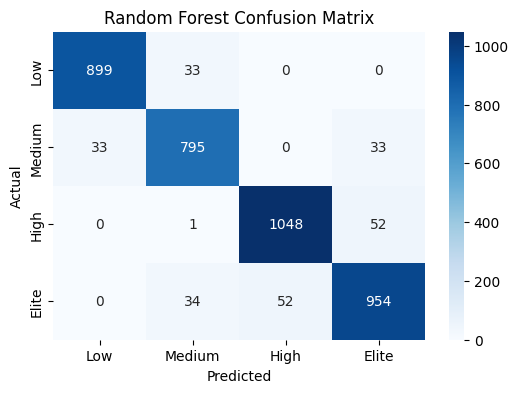


=== Before vs After Grid Search ===
Baseline Accuracy: 0.9362
Tuned Accuracy:   0.9395
Baseline F1:      0.9362
Tuned F1:         0.9395


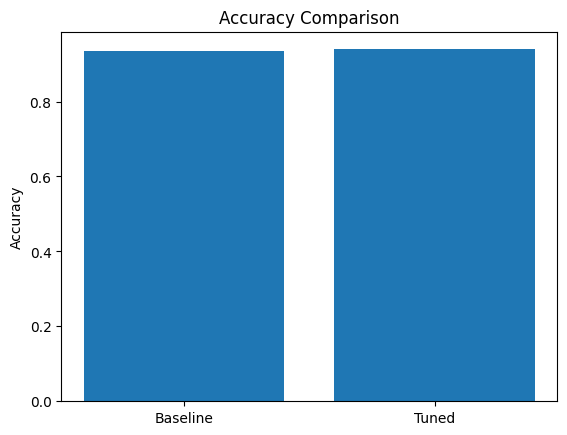


=== Cross Validation ===
Scores: [0.94534477 0.93708294 0.93009215 0.92720915 0.93547362]
Mean: 0.9350405263915966
Std: 0.006266630702054771


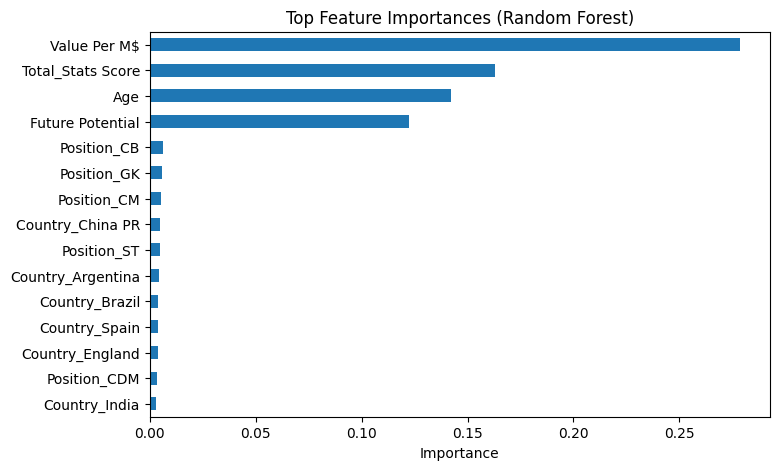

In [50]:
# Baseline Model

rf_baseline = RandomForestClassifier(random_state=42)

rf_baseline.fit(x2_train, y2_train_cat)

y_pred_base = rf_baseline.predict(x2_test)

baseline_acc = accuracy_score(y2_test_cat, y_pred_base)
baseline_f1 = f1_score(y2_test_cat, y_pred_base, average="weighted")

print("\n=== Baseline Random Forest ===")
print("Accuracy:", baseline_acc)
print("F1 Score:", baseline_f1)
print(classification_report(y2_test_cat, y_pred_base))


# Grid Search

param_grid_rf = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20, 30],
    "min_samples_leaf": [1, 2],
    "min_samples_split": [2, 5],
    "max_features": ["sqrt"]
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=param_grid_rf,
    cv=skf,
    scoring="accuracy",
    n_jobs=-1
)

grid_rf.fit(x2_train, y2_train_cat)

best_rf = grid_rf.best_estimator_

print("\n=== Best Parameters ===")
print(grid_rf.best_params_)
print("Best CV Accuracy:", grid_rf.best_score_)


# Evaluation

y_pred = best_rf.predict(x2_test)

rf_acc = accuracy_score(y2_test_cat, y_pred)
rf_f1 = f1_score(y2_test_cat, y_pred, average="weighted")

print("\n=== Tuned Random Forest ===")
print("Accuracy:", rf_acc)
print("F1 Score:", rf_f1)
print(classification_report(y2_test_cat, y_pred))


# Confusion Matrix

cm = confusion_matrix(y2_test_cat, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Low","Medium","High","Elite"],
            yticklabels=["Low","Medium","High","Elite"])
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# Comparison

print("\n=== Before vs After Grid Search ===")
print(f"Baseline Accuracy: {baseline_acc:.4f}")
print(f"Tuned Accuracy:   {rf_acc:.4f}")
print(f"Baseline F1:      {baseline_f1:.4f}")
print(f"Tuned F1:         {rf_f1:.4f}")

plt.figure()
plt.bar(["Baseline", "Tuned"], [baseline_acc, rf_acc])
plt.title("Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()


# Stability (Cross Validation)

rf_clf_cv_scores = cross_val_score(
    best_rf,
    x2_train,
    y2_train_cat,
    cv=skf,
    scoring="accuracy"
)

print("\n=== Cross Validation ===")
print("Scores:", rf_clf_cv_scores)
print("Mean:", rf_clf_cv_scores.mean())
print("Std:", rf_clf_cv_scores.std())


# Feature Importance

importances = pd.Series(
    best_rf.feature_importances_,
    index=x2_train.columns
).sort_values(ascending=True)

plt.figure(figsize=(8,5))
importances.tail(15).plot(kind='barh')
plt.title("Top Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.show()

In [79]:
train_pred_rf = best_rf.predict(x2_train)

train_acc = accuracy_score(
    y2_train_cat,
    train_pred_rf
)

train_f1 = f1_score(
    y2_train_cat,
    train_pred_rf,
    average="weighted"
)

test_acc = rf_acc
test_f1 = rf_f1

print("\n=== OVERFITTING CHECK ===")

print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test Accuracy:  {test_acc:.4f}")

print(f"\nTrain F1 Score: {train_f1:.4f}")
print(f"Test F1 Score:  {test_f1:.4f}")

acc_gap = train_acc - test_acc
f1_gap = train_f1 - test_f1

print(f"\nAccuracy Gap: {acc_gap:.4f}")
print(f"F1 Gap:       {f1_gap:.4f}")

if acc_gap > 0.2:
    print("Overfitting detected")
else:
    print("Good generalization")


=== OVERFITTING CHECK ===
Train Accuracy: 1.0000
Test Accuracy:  0.9395

Train F1 Score: 1.0000
Test F1 Score:  0.9395

Accuracy Gap: 0.0605
F1 Gap:       0.0605
Good generalization


- Random Forest (Regression)


=== Baseline Regression ===
RMSE: 6.339644509409297
R2: 0.12144470267118579
MAE: 1.3104757333502817

=== Best Parameters (Regression) ===
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best CV RMSE: 0.26706870935058347

=== Tuned Regression ===
RMSE: 6.357954751985595
R2: 0.1163624646080883
MAE: 1.3847409388239265

=== Comparison ===
Baseline RMSE: 6.3396
Tuned RMSE:   6.3580
Baseline R2:  0.1214
Tuned R2:     0.1164


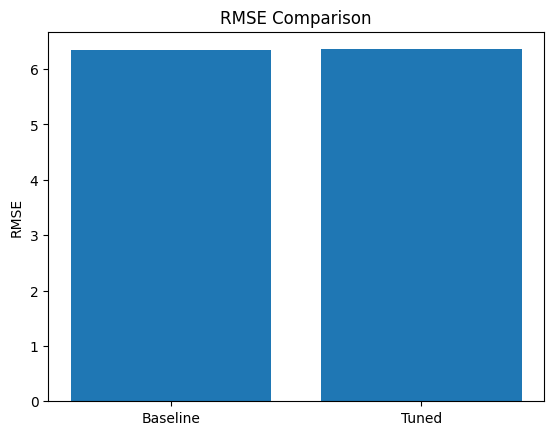


=== Cross Validation (Regression) ===
Fold RMSE: [0.27244928 0.27393508 0.27966702 0.2524317  0.25686047]
Mean RMSE: 0.26706870935058347
Std RMSE: 0.010519174889716416


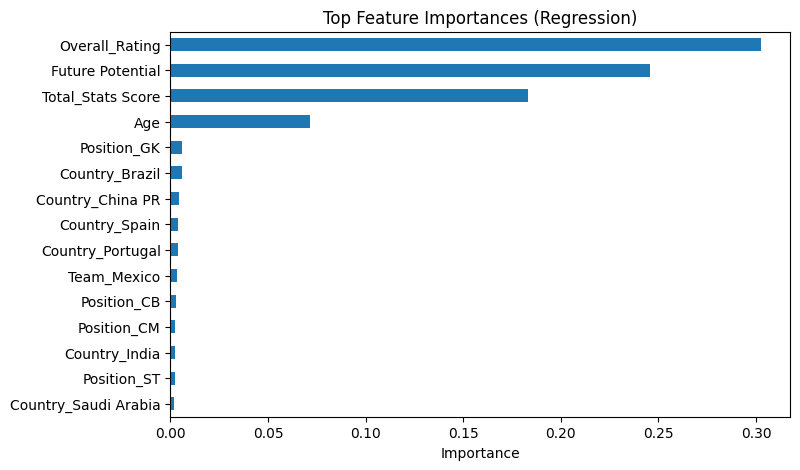

In [51]:
# Baseline Model
rf_baseline_reg = RandomForestRegressor(random_state=42)

rf_baseline_reg.fit(x1_train, y1_train)

y_pred_base_reg = rf_baseline_reg.predict(x1_test)

baseline_rmse = np.sqrt(mean_squared_error(y1_test, y_pred_base_reg))
baseline_r2 = r2_score(y1_test, y_pred_base_reg)
baseline_mae = mean_absolute_error(y1_test, y_pred_base_reg)

print("\n=== Baseline Regression ===")
print("RMSE:", baseline_rmse)
print("R2:", baseline_r2)
print("MAE:", baseline_mae)


# Grid Search
param_grid_reg = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20, 30],
    "min_samples_leaf": [1, 2],
    "min_samples_split": [2, 5],
    "max_features": ["sqrt"]
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)

grid_rf_reg = GridSearchCV (
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid=param_grid_reg,
    cv=kf,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

grid_rf_reg.fit(x1_train, y1_train)

best_rf_reg = grid_rf_reg.best_estimator_

print("\n=== Best Parameters (Regression) ===")
print(grid_rf_reg.best_params_)
print("Best CV RMSE:", -grid_rf_reg.best_score_)

# Evaluation
y_pred_reg = best_rf_reg.predict(x1_test)

tuned_rmse = np.sqrt(mean_squared_error(y1_test, y_pred_reg))
tuned_r2 = r2_score(y1_test, y_pred_reg)
tuned_mae = mean_absolute_error(y1_test, y_pred_reg)

print("\n=== Tuned Regression ===")
print("RMSE:", tuned_rmse)
print("R2:", tuned_r2)
print("MAE:", tuned_mae)


# Comparison
print("\n=== Comparison ===")
print(f"Baseline RMSE: {baseline_rmse:.4f}")
print(f"Tuned RMSE:   {tuned_rmse:.4f}")
print(f"Baseline R2:  {baseline_r2:.4f}")
print(f"Tuned R2:     {tuned_r2:.4f}")

plt.figure()
plt.bar(["Baseline", "Tuned"], [baseline_rmse, tuned_rmse])
plt.title("RMSE Comparison")
plt.ylabel("RMSE")
plt.show()


# Stability (Cross Validation)
rf_reg_cv_scores = cross_val_score(
    best_rf_reg,
    x1_train,
    y1_train,
    cv=kf,
    scoring="neg_root_mean_squared_error"
)

rmse_scores = -rf_reg_cv_scores

print("\n=== Cross Validation (Regression) ===")
print("Fold RMSE:", rmse_scores)
print("Mean RMSE:", rmse_scores.mean())
print("Std RMSE:", rmse_scores.std())


# Feature Importance
importances = pd.Series(
    best_rf_reg.feature_importances_,
    index=x1_train.columns
).sort_values(ascending=True)

plt.figure(figsize=(8,5))
importances.tail(15).plot(kind='barh')
plt.title("Top Feature Importances (Regression)")
plt.xlabel("Importance")
plt.show()

In [ ]:
train_pred = best_rf_reg.predict(x1_train)

train_rmse = np.sqrt(mean_squared_error(y1_train, train_pred))
train_r2 = r2_score(y1_train, train_pred)

print("\n=== OVERFITTING CHECK ===")
print(f"Train RMSE: {train_rmse:.4f}")
print(f"Test RMSE:  {tuned_rmse:.4f}")
print(f"Train R2:   {train_r2:.4f}")
print(f"Test R2:    {tuned_r2:.4f}")

gap = train_r2 - tuned_r2
print(f"\nR2 Gap: {gap:.4f}")

if gap > 0.2:
    print("Overfitting detected")
else:
    print("Good generalization")


=== OVERFITTING CHECK ===
Train RMSE: 0.0954
Test RMSE:  6.3545
Train R2:   0.9928
Test R2:    0.1173

R2 Gap: 0.8755
Overfitting detected


### Kernal-Based algorithm (SVM)

SVM is ideal because it performs exceptionally well in the high-dimensional spaces created after One-Hot Encoding the player's categorical information.

The FIFA dataset includes many encoded categorical features, and SVM is effective at finding optimal decision boundaries between classes in such spaces.
Using kernel methods also allows SVM to capture complex and non-linear relationships between player statistics and performance categories.

- SVM (Classification)


===SVM Baseline Comparison ===

SVM (RBF)
Accuracy: 0.8787
              precision    recall  f1-score   support

       Elite       0.95      0.94      0.95       932
        High       0.85      0.83      0.84       861
         Low       0.90      0.91      0.91      1101
      Medium       0.81      0.82      0.82      1040

    accuracy                           0.88      3934
   macro avg       0.88      0.88      0.88      3934
weighted avg       0.88      0.88      0.88      3934


SVM (Linear)
Accuracy: 0.8508
              precision    recall  f1-score   support

       Elite       0.92      0.91      0.91       932
        High       0.79      0.79      0.79       861
         Low       0.90      0.90      0.90      1101
      Medium       0.79      0.80      0.80      1040

    accuracy                           0.85      3934
   macro avg       0.85      0.85      0.85      3934
weighted avg       0.85      0.85      0.85      3934


SVM (Poly)
Accuracy: 0.8368
          

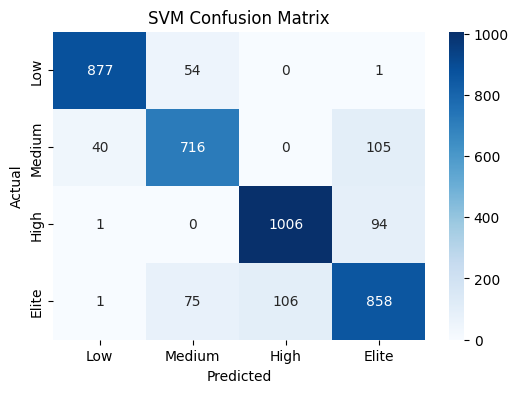


=== SVM Comparison ===
Best Baseline Accuracy: 0.8787
Tuned Accuracy:        0.8787

===  Cross Validation ===
Scores: [0.87766126 0.87607245 0.87384811 0.87412587 0.86713287]
Mean: 0.8737681130436137
Std: 0.003595204558083472


In [52]:
#  Baseline
svm_models = {
    "SVM (RBF)": SVC(kernel='rbf'),
    "SVM (Linear)": SVC(kernel='linear'),
    "SVM (Poly)": SVC(kernel='poly', degree=3)
}

results = {}

print("\n===SVM Baseline Comparison ===")

for name, model in svm_models.items():

    model.fit(x2_train, y2_train_cat)
    y_pred = model.predict(x2_test)

    acc = accuracy_score(y2_test_cat, y_pred)
    results[name] = acc

    print(f"\n{name}")
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y2_test_cat, y_pred))


# Best Baseline Model
best_model_name = max(results, key=results.get)
print("\n Best SVM Baseline:", best_model_name)


# Grid Search
param_grid = {
    "C": [0.1, 1, 10],
    "kernel": ["rbf", "linear"],
    "gamma": ["scale", "auto"]
}

grid_svm = GridSearchCV(
    estimator=SVC(),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_svm.fit(x2_train, y2_train_cat)

best_svm = grid_svm.best_estimator_

print("\n=== Best Params ===")
print(grid_svm.best_params_)



# Final Evaluation
y_pred = best_svm.predict(x2_test)

tuned_acc = accuracy_score(y2_test_cat, y_pred)

print("\n===  Tuned SVM ===")
print("Accuracy:", tuned_acc)
print(classification_report(y2_test_cat, y_pred))


# Confusion Matrix
cm = confusion_matrix(y2_test_cat, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Low","Medium","High","Elite"],
            yticklabels=["Low","Medium","High","Elite"])
plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# Comparison
print("\n=== SVM Comparison ===")
print(f"Best Baseline Accuracy: {results[best_model_name]:.4f}")
print(f"Tuned Accuracy:        {tuned_acc:.4f}")


# Stability (Cross Validation)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

svm_clf_cv_scores = cross_val_score(best_svm, x2_train, y2_train_cat, cv=skf)


print("\n===  Cross Validation ===")
print("Scores:", svm_clf_cv_scores)
print("Mean:", svm_clf_cv_scores.mean())
print("Std:", svm_clf_cv_scores.std())

In [83]:
train_pred_svm = best_svm.predict(x2_train)

train_acc = accuracy_score(y2_train_cat, train_pred_svm)
train_f1 = f1_score(y2_train_cat, train_pred_svm, average="weighted")

test_acc = tuned_acc
test_pred_svm = best_svm.predict(x2_test)
test_f1 = f1_score(y2_test_cat, test_pred_svm, average="weighted")

print("\n=== OVERFITTING CHECK ===")
print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test Accuracy:  {test_acc:.4f}")

print(f"\nTrain F1 Score: {train_f1:.4f}")
print(f"Test F1 Score:  {test_f1:.4f}")

gap = train_acc - test_acc
f1_gap = train_f1 - test_f1

print(f"\nAccuracy Gap: {gap:.4f}")
print(f"F1 Gap:       {f1_gap:.4f}")

if gap > 0.2:
    print("Overfitting detected")
else:
    print("Good generalization")


=== OVERFITTING CHECK ===
Train Accuracy: 0.9277
Test Accuracy:  0.8787

Train F1 Score: 0.9279
Test F1 Score:  0.8789

Accuracy Gap: 0.0489
F1 Gap:       0.0490
Good generalization


- SVM (Regression)


=== SVR Baseline ===
RMSE: 6.345018630069425
R2: 0.11995456758217082

===  Best Params (SVR) ===
{'C': 10, 'epsilon': 0.1, 'gamma': 'scale', 'kernel': 'rbf'}

=== Tuned SVR ===
RMSE: 6.345318168447273
R2: 0.1198714744917092

===  SVR Comparison ===
Baseline RMSE: 6.3450
Tuned RMSE:   6.3453


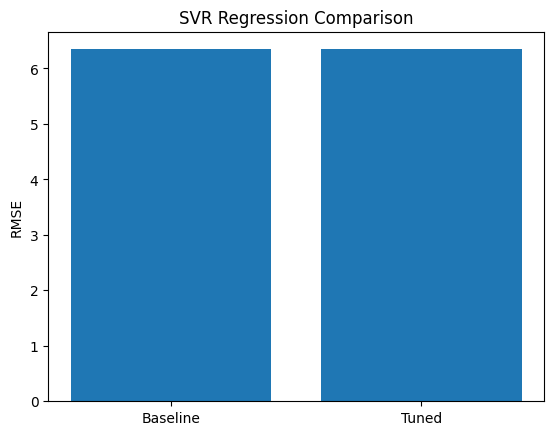


=== Cross Validation ===
Scores: [0.22646814 0.246325   0.24706826 0.22160426 0.226885  ]
Mean RMSE: 0.23367013232745207
Std: 0.01079951384885983


In [53]:
# Basline
svr_baseline = SVR()

svr_baseline.fit(x1_train, y1_train)

y_pred_base = svr_baseline.predict(x1_test)

baseline_rmse = np.sqrt(mean_squared_error(y1_test, y_pred_base))
baseline_r2 = r2_score(y1_test, y_pred_base)

print("\n=== SVR Baseline ===")
print("RMSE:", baseline_rmse)
print("R2:", baseline_r2)


# Grid Search
param_grid_svr = {
    "C": [0.1, 1, 10],
    "epsilon": [0.1, 0.5, 1],
    "kernel": ["rbf", "linear"],
    "gamma": ["scale", "auto"]
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)

grid_svr = GridSearchCV(
    estimator=SVR(),
    param_grid=param_grid_svr,
    cv=kf,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

grid_svr.fit(x1_train, y1_train)

best_svr = grid_svr.best_estimator_

print("\n===  Best Params (SVR) ===")
print(grid_svr.best_params_)


# Evaluation
y_pred = best_svr.predict(x1_test)

tuned_rmse = np.sqrt(mean_squared_error(y1_test, y_pred))
tuned_r2 = r2_score(y1_test, y_pred)

print("\n=== Tuned SVR ===")
print("RMSE:", tuned_rmse)
print("R2:", tuned_r2)


# Comparison
print("\n===  SVR Comparison ===")
print(f"Baseline RMSE: {baseline_rmse:.4f}")
print(f"Tuned RMSE:   {tuned_rmse:.4f}")


# Visalization
plt.figure()
plt.bar(["Baseline", "Tuned"], [baseline_rmse, tuned_rmse])
plt.title("SVR Regression Comparison")
plt.ylabel("RMSE")
plt.show()


# Stability (Cross Validation)
svm_reg_cv_scores = cross_val_score(
    best_svr,
    x1_train,
    y1_train,
    cv=kf,
    scoring="neg_root_mean_squared_error"
)

print("\n=== Cross Validation ===")
print("Scores:", -svm_reg_cv_scores)
print("Mean RMSE:", -svm_reg_cv_scores.mean())
print("Std:", svm_reg_cv_scores.std())

In [ ]:
train_pred_svr = best_svr.predict(x1_train)

train_r2 = r2_score(y1_train, train_pred_svr)

print("\n=== OVERFITTING CHECK ===")
print(f"Train R2: {train_r2:.4f}")
print(f"Test R2:  {tuned_r2:.4f}")

gap = train_r2 - tuned_r2
print(f"\nR2 Gap: {gap:.4f}")

if gap > 0.2:
    print("Overfitting detected")
else:
    print("Good generalization")


=== OVERFITTING CHECK ===
Train R2: 0.9955
Test R2:  0.1173

R2 Gap: 0.8781
 Overfitting detected


### Ensembling (Stacking)

Stacking was selected because it combines the strengths of multiple models instead of relying on a single algorithm. Each model learns patterns differently, so combining them can improve overall performance and reduce individual model weaknesses.

For classification and regression tasks, stacking helps achieve better generalization by using the predictions of several strong base models and training a final model to make the best overall decision.

- Stacking Classification

In [54]:
print("="*35)
print("All Model Stacking Classification")
print("="*35)

# Define ALL Classification Models as Base Estimators
clf_estimators_all = [
    ('rf', best_rf),
    ('knn', best_knn_clf),
    ('svm', best_svm),
    ('log_reg_l1', model_l1),
]

# Initialize the Stacking Classifier
stack_clf_all = StackingClassifier(
    estimators=clf_estimators_all,
    final_estimator=LogisticRegression(max_iter=2000),
    cv=5,
    n_jobs=-1
)

# Train the Ensemble
stack_clf_all.fit(x2_train, y2_train_cat)

# Evaluate Performance
y_pred_stack_clf_all = stack_clf_all.predict(x2_test)
stack_all_acc = accuracy_score(y2_test_cat, y_pred_stack_clf_all)
print(f"Accuracy: {stack_all_acc:.4f}")
print(classification_report(y2_test_cat, y_pred_stack_clf_all))

All Model Stacking Classification
Accuracy: 0.9398
              precision    recall  f1-score   support

       Elite       0.96      0.97      0.97       932
        High       0.93      0.92      0.92       861
         Low       0.95      0.96      0.95      1101
      Medium       0.92      0.91      0.92      1040

    accuracy                           0.94      3934
   macro avg       0.94      0.94      0.94      3934
weighted avg       0.94      0.94      0.94      3934



- Stacking Regression

In [55]:
print("="*35)
print("All Model Stacking Regression")
print("="*35)

lasso_pipeline = Pipeline([
    ('preprocessor', preprocessor_reg),
    ('lasso', Lasso(alpha=best_alpha_lasso, max_iter=2000))
])

# Define ALL Regression Models as Base Estimators
reg_estimators_all = [
    ('svr', best_svr),
    ('rf', best_rf_reg),
    ('knn', best_knn_reg),
    ('ridge_poly', best_reg_pipeline),
    ('lasso_poly', lasso_pipeline)
]

# Initialize the Stacking Regressor
stack_reg_all = StackingRegressor (
    estimators=reg_estimators_all,
    final_estimator=Ridge(),
    cv=5,
    n_jobs=-1
)

# Train the Ensemble
stack_reg_all.fit(x1_train, y1_train)

# Evaluate Performance
y_pred_stack_all = stack_reg_all.predict(x1_test)
stack_all_rmse = np.sqrt(mean_squared_error(y1_test, y_pred_stack_all))
stack_all_r2 = r2_score(y1_test, y_pred_stack_all)
print(f"RMSE: {stack_all_rmse:.4f}")
print(f"R2 Score: {stack_all_r2:.4f}")

All Model Stacking Regression
RMSE: 6.3410
R2 Score: 0.1211


### Bias–Variance Analysis (Overfitting Check)

We evaluate model performance on both training and testing data to detect overfitting.
For classification, we compare accuracy scores, and for regression, we compare R² scores.

- Bias / Variance Analysis Classification

In [56]:
train_pred_clf = stack_clf_all.predict(x2_train)
test_pred_clf = stack_clf_all.predict(x2_test)
train_acc = accuracy_score (
    y2_train_cat,
    train_pred_clf
)

test_acc = accuracy_score (
    y2_test_cat,
    test_pred_clf
)

print("\n" + "="*35)
print("Bias / Variance Analysis")
print("="*35)

print(f"Train Accuracy : {train_acc:.4f}")
print(f"Test Accuracy  : {test_acc:.4f}")


# Overfitting Check

gap = abs(train_acc - test_acc)
print(f"\nTrain-Test Gap : {gap:.4f}")
if gap < 0.1:
    print("Good Generalization (Low Variance)")

else:
    print("Possible Overfitting (High Variance)")


Bias / Variance Analysis
Train Accuracy : 0.9999
Test Accuracy  : 0.9398

Train-Test Gap : 0.0601
Good Generalization (Low Variance)


- Bias / Variance Analysis Regression

In [57]:
train_pred_stack = stack_reg_all.predict(x1_train)
test_pred_stack = stack_reg_all.predict(x1_test)

train_r2 = r2_score (
    y1_train,
    train_pred_stack
)

test_r2 = r2_score (
    y1_test,
    test_pred_stack
)

print("\n" + "="*35)
print("Bias / Variance Analysis")
print("="*35)

print(f"Train R2 Score : {train_r2:.4f}")
print(f"Test R2 Score  : {test_r2:.4f}")


# Overfitting Check
gap = abs(train_r2 - test_r2)
print(f"\nTrain-Test Gap : {gap:.4f}")
if gap < 0.1:
    print("Good Generalization (Low Variance)")
else:
    print("Possible Overfitting (High Variance)")


Bias / Variance Analysis
Train R2 Score : 0.9964
Test R2 Score  : 0.1211

Train-Test Gap : 0.8754
Possible Overfitting (High Variance)


### System Comparison

In [58]:
# Individual Regression Model Metrics

# SVR
best_svr.fit(x1_train, y1_train)
y_pred_svr = best_svr.predict(x1_test)
svr_rmse = np.sqrt(mean_squared_error(y1_test, y_pred_svr))
svr_r2 = r2_score(y1_test,y_pred_svr)

# Random Forest
best_rf_reg.fit(x1_train, y1_train)
y_pred_rf = best_rf_reg.predict(x1_test)
rf_rmse = np.sqrt(mean_squared_error(y1_test, y_pred_rf))
rf_r2 = r2_score(y1_test,y_pred_rf)

# KNN
best_knn_reg.fit(x1_train, y1_train)
y_pred_knn = best_knn_reg.predict(x1_test)
knn_rmse = np.sqrt(mean_squared_error(y1_test, y_pred_knn))
knn_r2 = r2_score(y1_test,y_pred_knn)

# Ridge + Polynomial
best_reg_pipeline.fit(x1_train, y1_train)
y_pred_ridge = best_reg_pipeline.predict(x1_test)
ridge_rmse = np.sqrt(mean_squared_error(y1_test, y_pred_ridge))
ridge_r2 = r2_score(y1_test,y_pred_ridge)


Regression Models VS Stacking
SVR RMSE                : 6.3453
Random Forest RMSE      : 6.3580
KNN RMSE                : 6.3545
Ridge Poly RMSE         : 6.3175
--------------------------------------------------
Stacking RMSE           : 6.3410


SVR R2 Score            : 0.1199
Random Forest R2 Score  : 0.1164
KNN R2 Score            : 0.1173
Ridge Poly R2 Score     : 0.1276
--------------------------------------------------
Stacking R2 Score       : 0.1211


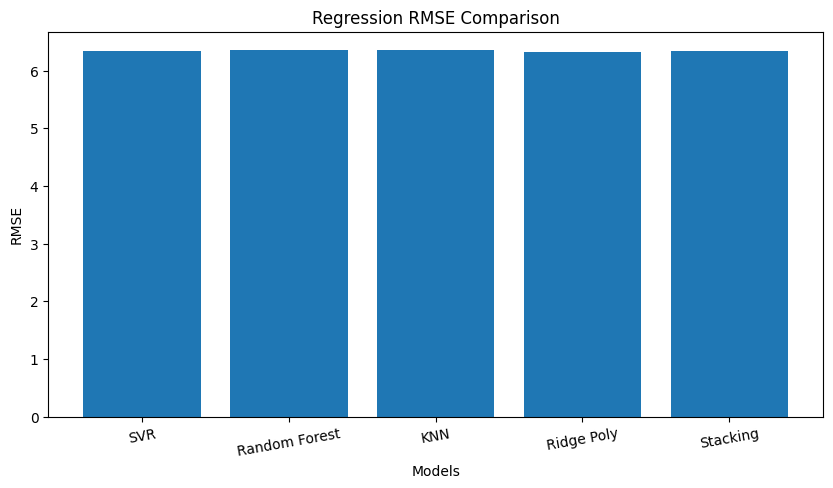

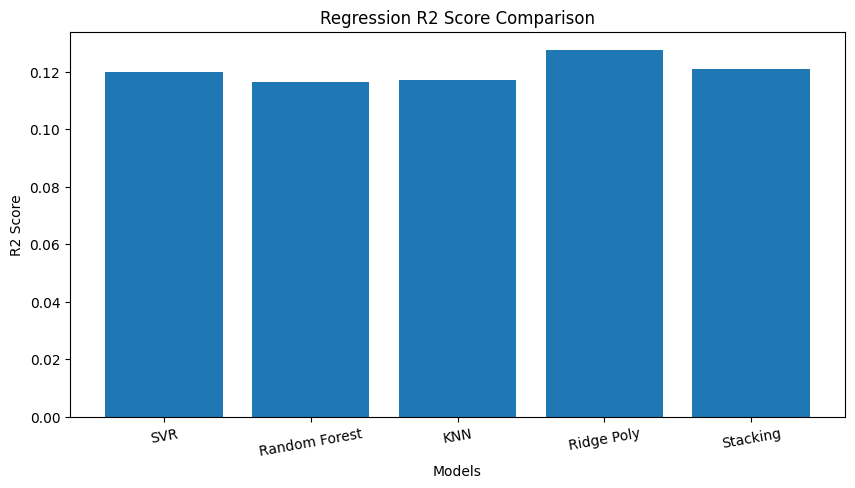

In [59]:
# Comparision - Indevidual Models vs Stacking
print("\n" + "="*50)
print("Regression Models VS Stacking")
print("="*50)

print(f"SVR RMSE                : {svr_rmse:.4f}")
print(f"Random Forest RMSE      : {rf_rmse:.4f}")
print(f"KNN RMSE                : {knn_rmse:.4f}")
print(f"Ridge Poly RMSE         : {ridge_rmse:.4f}")

print("-"*50)

print(f"Stacking RMSE           : {stack_all_rmse:.4f}")

print("\n")

print(f"SVR R2 Score            : {svr_r2:.4f}")
print(f"Random Forest R2 Score  : {rf_r2:.4f}")
print(f"KNN R2 Score            : {knn_r2:.4f}")
print(f"Ridge Poly R2 Score     : {ridge_r2:.4f}")

print("-"*50)

print(f"Stacking R2 Score       : {stack_all_r2:.4f}")

# Visualisation (RMSE)
models = [
    'SVR',
    'Random Forest',
    'KNN',
    'Ridge Poly',
    'Stacking'
]
rmse_scores = [
    svr_rmse,
    rf_rmse,
    knn_rmse,
    ridge_rmse,
    stack_all_rmse
]
plt.figure(figsize=(10,5))
plt.bar(models, rmse_scores)
plt.title("Regression RMSE Comparison")
plt.xlabel("Models")
plt.ylabel("RMSE")
plt.xticks(rotation=10)
plt.show()

# Visualisation (R2 SCORE)
r2_scores = [
    svr_r2,
    rf_r2,
    knn_r2,
    ridge_r2,
    stack_all_r2
]
plt.figure(figsize=(10,5))
plt.bar(models, r2_scores)
plt.title("Regression R2 Score Comparison")
plt.xlabel("Models")
plt.ylabel("R2 Score")
plt.xticks(rotation=10)
plt.show()

In [60]:
# Individual Model Accuracies

# Random Forest
rf_acc = accuracy_score(
    y2_test_cat,
    best_rf.predict(x2_test)
)

# KNN
knn_acc = accuracy_score(
    y2_test_cat,
    best_knn_clf.predict(x2_test)
)

# SVM
svm_acc = accuracy_score(
    y2_test_cat,
    best_svm.predict(x2_test)
)

# Logistic Regression
log_acc = accuracy_score(
    y2_test_cat,
    model_l1.predict(x2_test)
)

In [61]:
print("\n" + "="*50)
print("Individual Models VS Stacking")
print("="*50)
print(f"Random Forest Accuracy       : {rf_acc:.4f}")
print(f"KNN Accuracy                 : {knn_acc:.4f}")
print(f"SVM Accuracy                 : {svm_acc:.4f}")
print(f"Logistic Regression Accuracy : {log_acc:.4f}")
print("-"*50)
print(f"Stacking Accuracy            : {stack_all_acc:.4f}")


Individual Models VS Stacking
Random Forest Accuracy       : 0.9395
KNN Accuracy                 : 0.7974
SVM Accuracy                 : 0.8787
Logistic Regression Accuracy : 0.8457
--------------------------------------------------
Stacking Accuracy            : 0.9398


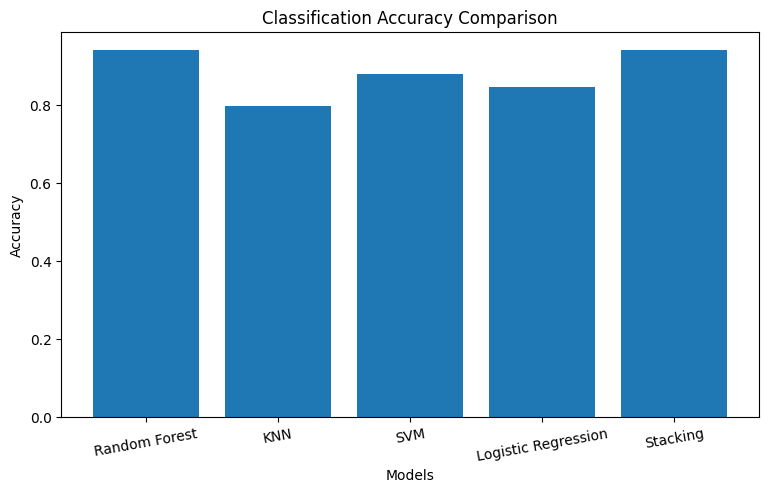

In [62]:
models = [
    "Random Forest",
    "KNN",
    "SVM",
    "Logistic Regression",
    "Stacking"
]

accuracies = [
    rf_acc,
    knn_acc,
    svm_acc,
    log_acc,
    stack_all_acc
]

plt.figure(figsize=(9,5))
plt.bar(models, accuracies)
plt.title("Classification Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.xticks(rotation=10)
plt.show()

In [63]:
# Fix Length Issue
y2_train_cat = y2_train_cat.loc[x2_train.index]

# Cross Validation
cv_scores_clf = cross_val_score(
    stack_clf_all,
    x2_train,
    y2_train_cat,
    cv=5,
    scoring='accuracy'
)

print("\n" + "="*35)
print("Stacking Classification CV")
print("="*35)

print("CV Scores:", cv_scores_clf)

print("Mean Accuracy:", cv_scores_clf.mean())

print("Std:", cv_scores_clf.std())


Stacking Classification CV
CV Scores: [0.94184938 0.93390531 0.93390531 0.93769866 0.93452003]
Mean Accuracy: 0.93637573680905
Std: 0.003077681849178517


### Unified Pipeline

We built a unified function to handle both regression and classification in one pipeline. The model automatically detects the task based on available target data, then applies the correct preprocessing, scaling, and stacking model.

In [64]:
# Column Definitions
cat_cols = ['Country', 'Position', 'Team']

num_cols_reg = [
    'Age',
    'Overall_Rating',
    'Future Potential',
    'Total_Stats Score'
]

num_cols_clf = [
    'Age',
    'Value Per M$',
    'Future Potential',
    'Total_Stats Score'
]

# Encoding Setup
encoder_x1 = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

encoder_x2 = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

encoder_x1.fit(x1_train_raw[cat_cols])
encoder_x2.fit(x2_train_raw[cat_cols])

# Unified Scout Function
def unified_player_scout(new_player_data):

    print("\n" + "="*50)
    print("Unified Scouting System")
    print("="*50)

    for idx in range(len(new_player_data)):
        player = new_player_data.iloc[[idx]].copy()

        player_name = player["Name"].values[0]

        print("\n" + "-"*40)
        print(f"Player: {player_name}")
        print("-"*40)

        # Remove Name
        player = player.drop(columns=["Name"])

        # Automatic Task Detection
        if pd.notna(player["Overall_Rating"].values[0]):
            task = "Regression"

            encoder = encoder_x1
            scaler = scaler1
            model = stack_reg_all
            train_columns = x1_train.columns
            num_cols = num_cols_reg

            print("Detected Task: Regression")

        elif pd.notna(player["Value Per M$"].values[0]):
            task = "Classification"

            encoder = encoder_x2
            scaler = scaler2
            model = stack_clf_all
            train_columns = x2_train.columns
            num_cols = num_cols_clf

            print("Detected Task: Classification")

        else:
            print("Could not detect task.")
            continue

        # One-hot encoding
        encoded = encoder.transform(player[cat_cols])

        encoded_df = pd.DataFrame(
            encoded,
            columns=encoder.get_feature_names_out(cat_cols),
            index=player.index
        )

        player = player.drop(columns=cat_cols)
        player = pd.concat([player, encoded_df], axis=1)

        player = player.reindex(
            columns=train_columns,
            fill_value=0
        )

        # Scaling
        player[num_cols] = scaler.transform(
            player[num_cols]
        )

        # Prediction
        prediction = model.predict(player)[0]

        # Output
        if task == "Regression":
            print(
                f"Predicted Value Per M$: "
                f"{round(prediction, 2)}"
            )

        else:
            print(
                f"Predicted Performance Tier: "
                f"{prediction}"
            )

# New Players
new_players = pd.DataFrame([
    # Regression Players
    ["Malak", "Egypt", "CB", 20, 68, 84, "Real Madrid", None, 1520],
    ["Mn3m", "Egypt", "RB", 20, 65, 72, "Al Ahly", None, 1400],

    # Classification Players
    ["Hamsa", "Egypt", "CF", 24, None, 70, "Zamalek", 1, 1500],
    ["Hla", "Egypt", "ST", 20, None, 80, "Arsenal", 3, 1600],
    ["Kareem", "Egypt", "CM", 30, None, 60, "Inter Milan", 0.5, 1350]
], columns=[
    "Name",
    "Country",
    "Position",
    "Age",
    "Overall_Rating",
    "Future Potential",
    "Team",
    "Value Per M$",
    "Total_Stats Score"
])

unified_player_scout(new_players)


Unified Scouting System

----------------------------------------
Player: Malak
----------------------------------------
Detected Task: Regression
Predicted Value Per M$: 2.46

----------------------------------------
Player: Mn3m
----------------------------------------
Detected Task: Regression
Predicted Value Per M$: 1.04

----------------------------------------
Player: Hamsa
----------------------------------------
Detected Task: Classification
Predicted Performance Tier: High

----------------------------------------
Player: Hla
----------------------------------------
Detected Task: Classification
Predicted Performance Tier: Elite

----------------------------------------
Player: Kareem
----------------------------------------
Detected Task: Classification
Predicted Performance Tier: Medium


- Another approach for unified pipline

This version improves the original unified system by making it more modular and flexible. Instead of working only with DataFrames inside the loop, it also supports dictionary input directly, which makes it easier to use in real applications or APIs.

In [65]:
# def unified_player_scout(player_row):
#     if isinstance(player_row, dict):
#         df = pd.DataFrame([player_row])
#     else:
#         df = player_row.copy()

#     if 'Name' in df.columns:
#         df = df.drop(columns=['Name'])

#     # Task Detection
#     if 'Overall_Rating' in df.columns:
#         task = "Regression"
#         num_cols = ['Age', 'Overall_Rating', 'Future Potential', 'Total_Stats Score']
#         model = stack_reg_all
#         encoder = encoder_x1
#         scaler = scaler1
#         train_cols = x1_train.columns
#     elif 'Value Per M$' in df.columns:
#         task = "Classification"
#         num_cols = ['Age', 'Value Per M$', 'Future Potential', 'Total_Stats Score']
#         model = stack_clf_all
#         encoder = encoder_x2
#         scaler = scaler2
#         train_cols = x2_train.columns
#     else:
#         return "Could not detect task. Please provide 'Overall_Rating' or 'Value Per M$'."

#     cat_cols = ['Country', 'Position', 'Team']

#     # One Hot Encoding
#     encoded = encoder.transform(df[cat_cols])
#     encoded_df = pd.DataFrame(
#         encoded,
#         columns=encoder.get_feature_names_out(cat_cols), 
#         index=df.index
#     )
#     df = df.drop(columns=cat_cols)
#     df = pd.concat([df, encoded_df], axis=1)

#     df = df.reindex(columns=train_cols, fill_value=0)

#     # Scaling
#     df[num_cols] = scaler.transform(df[num_cols])

#     # Prediction
#     prediction = model.predict(df)[0]

#     # Format the output
#     if task == "Regression":
#         return {
#             "Detected Task": "Regression",
#             "Predicted Value Per M$": round(prediction, 2)
#         }
#     else:
#         return {
#             "Detected Task": "Classification",
#             "Predicted Tier": prediction
#         }


# print("\n" + "="*40)
# print("Testing Unified Scouting System")
# print("="*40)

# # Predict Market Value
# player_a = {
#     "Name": "Malak", "Country": "Egypt", "Position": "CB",
#     "Age": 20, "Overall_Rating": 68, "Future Potential": 84,
#     "Team": "Real Madrid", "Total_Stats Score": 1520
# }

# # Predict Performance Tier
# player_b = {
#     "Name": "Hamsa", "Country": "Egypt", "Position": "CF",
#     "Age": 24, "Future Potential": 70, "Team": "Zamalek",
#     "Value Per M$": 1, "Total_Stats Score": 1500
# }

# print(f"Player A: {unified_player_scout(player_a)}")
# print(f"Player B: {unified_player_scout(player_b)}")

### JSON File

In [84]:
# Group Information
group_members = [
    {
        "name": "Youssef Abdulmonem Mohamed Elkermany",
        "id": 2406249130
    },
    {
        "name": "Kareem Mohamed Abdelghany Elramady",
        "id": 2406247728
    },
    {
        "name": "Malak Ashraf Rezk Adam Ahmed",
        "id": 2406244711
    },
    {
        "name": "Hamsa Ihab Mohamed Khairy",
        "id": 2406244140
    },
    {
        "name": "Hla Essam Abo El-wafa Aly",
        "id": 2406242151
    }
]

# Best Hyperparameters
best_hyperparameters = {
    "KNN_Classifier": {
        "n_neighbors": int(best_knn_clf.n_neighbors),
        "metric": best_knn_clf.metric
    },

    "KNN_Regressor": {
        "n_neighbors": int(best_knn_reg.n_neighbors),
        "metric": best_knn_reg.metric
    },

    "Random_Forest_Classifier": grid_rf.best_params_,

    "Random_Forest_Regressor": grid_rf_reg.best_params_,

    "SVM_Classifier": grid_svm.best_params_,

    "SVR_Regressor": grid_svr.best_params_
}

# Cross Validation Stability
cv_stability = {

    "KNN_Classifier": {
        "mean": float(knn_clf_cv_scores.mean()),
        "std": float(knn_clf_cv_scores.std())
    },

    "KNN_Regressor": {
        "mean": float(knn_reg_cv_scores.mean()),
        "std": float(knn_reg_cv_scores.std())
    },

    "RF_Classifier": {
        "mean": float(rf_clf_cv_scores.mean()),
        "std": float(rf_clf_cv_scores.std())
    },

    "RF_Regression": {
        "mean": float(rf_reg_cv_scores.mean()),
        "std": float(rf_reg_cv_scores.std())
    },

    "SVM_Classification": {
        "mean": float(svm_clf_cv_scores.mean()),
        "std": float(svm_clf_cv_scores.std())
    },

    "SVM_Regression": {
        "mean": float((-svm_reg_cv_scores).mean()),
        "std": float(svm_reg_cv_scores.std())
    }
}

# Final JSON Structure
results = {
    "group_members": group_members,
    "best_hyperparameters": best_hyperparameters,
    "cv_stability": cv_stability
}

# Export JSON File
with open("results.json", "w") as f:
    json.dump(results, f, indent=4)